# Phase 1 — Emergency Vehicle Routing on Kanpur OSM Data
**Changes from original:**
1. City: Munich (local .osm file) → **Kanpur, India** (live OSM download)
2. Origin/Destination: arbitrary geometric points → **real hospital locations**
3. Edge weight: fixed 5 km/h walking → **road-type-based vehicle speed**
4. Algorithms: Two-Q + Dijkstra → **Two-Q + Dijkstra + A\***

## Cell 1 — Install Libraries

In [1]:
!pip install osmnx networkx geopandas folium matplotlib pandas numpy scipy tqdm shapely


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.1 MB/s eta 0:00:00


## Cell 2 — Imports

In [2]:
import pandas as pd
import geopandas as gpd                  # pandas + geographic geometry columns
import numpy as np
import math
import heapq                             # for priority queues
import time                              # measure execution speed
import random                            # pick random incident nodes for benchmark
import warnings
from collections import defaultdict      # defaultdict(lambda: inf) ─ avoids pre-filling dicts

from shapely.geometry import Point, LineString   # geographic geometry objects
import osmnx as ox                       # downloads OSM data
import networkx as nx                    # for osmx
import matplotlib.pyplot as plt
import folium                            # interactive maps
from folium.plugins import DualMap       # side-by-side map comparison
from tqdm import tqdm

warnings.filterwarnings('ignore')        # hide yellow warnings for cleaner output

# osmnx settings
ox.settings.use_cache = True             # cache downloaded data ─ 2nd run is instant
ox.settings.log_console = False          # don't print every API request to console

print("All libraries imported successfully.")
print(f"  osmnx   version: {ox.__version__}")
print(f"  networkx version: {nx.__version__}")

All libraries imported successfully.
  osmnx   version: 2.1.0
  networkx version: 3.6.1


## Cell 3 — Download Kanpur Road Network
Downloads live from OpenStreetMap for any city — no file needed.

In [3]:
print("Downloading Kanpur road network from OpenStreetMap...")

city_graph = ox.graph_from_place(
    query="Kanpur, Uttar Pradesh, India",

    network_type="drive",
    # Only drivable roads (cars/ambulances).
    # Options: "drive", "walk", "bike", "all"

    simplify=True,
    # Merge long chains of intermediate nodes into single edges.

    retain_all=False,
    # Drop disconnected road islands that can't be reached from the main network.
    # Keeps only the largest strongly-connected component.
)

print("Graph downloaded!")
print(f"  Nodes (intersections) : {city_graph.number_of_nodes():,}")
print(f"  Edges (road segments) : {city_graph.number_of_edges():,}")
print(f"  Graph type            : {type(city_graph).__name__}")
# MultiDiGraph = Directed (one-way streets respected) + Multi (parallel edges allowed)

Graph downloaded!
  Nodes (intersections) : 59,539
  Edges (road segments) : 159,598
  Graph type            : MultiDiGraph


## Cell 4 — Project Graph + Extract Nodes and Edges

In [4]:
city_graph_proj = ox.project_graph(city_graph)
# Reproject from lat/lon (degrees) → UTM (metres).
# UTM uses metres uniformly so distance calculations are accurate.

nodes_proj, edges_proj = ox.graph_to_gdfs(city_graph_proj, nodes=True, edges=True)
# Convert the NetworkX graph into two GeoDataFrames:
#   nodes_proj : one row per intersection  → columns: x, y, osmid, geometry(Point)
#   edges_proj : one row per road segment  → columns: length, highway, maxspeed,
#                lanes, oneway, geometry(LineString)
#                index: (u, v, k)  where u=from node, v=to node, k=parallel-edge key

print("CRS (Coordinate Reference System):", edges_proj.crs)
# e.g. EPSG:32644  = UTM Zone 44N (covers Kanpur)

print("\nAll edge attribute columns:")
print(list(edges_proj.columns))

print("\nSample edge rows:")
show = [c for c in ['length','highway','maxspeed','lanes','oneway'] if c in edges_proj.columns]
print(edges_proj[show].head(4).to_string())

CRS (Coordinate Reference System): EPSG:32644

All edge attribute columns:
['osmid', 'highway', 'oneway', 'reversed', 'length', 'lanes', 'name', 'ref', 'geometry', 'access', 'bridge', 'junction', 'maxspeed', 'tunnel']

Sample edge rows:
                               length   highway maxspeed lanes  oneway
u          v          key                                             
245748060  8839368227 0      9.488318  tertiary      NaN   NaN    True
           8336861318 0    126.608881     trunk      NaN     2    True
8839368227 8839368226 0      7.398168     trunk      NaN     2    True
           8395232941 0     70.519740  tertiary      NaN   NaN    True


## Cell 5 — Plot the Kanpur Road Network

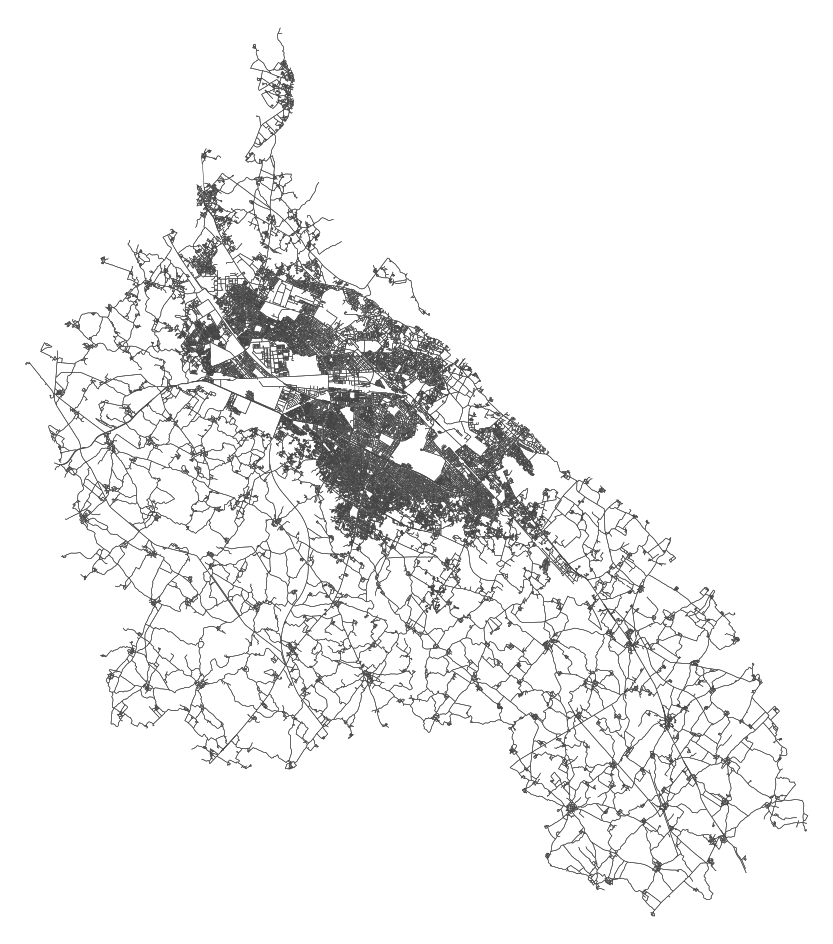

<Figure size 640x480 with 0 Axes>

Saved: kanpur_road_network.png


In [5]:
fig, ax = ox.plot_graph(
    city_graph,
    figsize=(14, 12),        # 14×12 inch figure
    node_size=0,             # hide intersection dots
    edge_color='#444444',    # dark grey roads
    edge_linewidth=0.4,      # thin lines so full city is visible
    bgcolor='white',         # clean white background
)
ax.set_title("Kanpur Road Network — OpenStreetMap", fontsize=16, pad=15)
plt.tight_layout()
plt.savefig('kanpur_road_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kanpur_road_network.png")

## Cell 6 — Fetch Real Hospital Locations
**Original code:**
`origin = centroid of convex hull` (geographic centre)
`target = node with minimum x` (westernmost point)
Both are arbitrary — not real emergency locations.
**New code:** query OpenStreetMap for actual hospitals via Overpass API.

In [6]:
print("Fetching hospitals from OpenStreetMap (Overpass API)...")

hospitals_gdf = None
hospitals_gdf = ox.features_from_place(
    query="Kanpur, Uttar Pradesh, India",
    tags={"amenity": "hospital"}
    # OSM tags are key-value pairs. amenity=hospital returns all hospitals.
    # Other useful tags: "amenity":"clinic", "amenity":"fire_station"
)
print(f"OSM returned {len(hospitals_gdf)} hospital features.")

# Drop rows with no geometry
hospitals_gdf = hospitals_gdf[hospitals_gdf.geometry.notna()].copy()
print(f"After removing null geometry: {len(hospitals_gdf)} hospitals.")

Fetching hospitals from OpenStreetMap (Overpass API)...
OSM returned 204 hospital features.
After removing null geometry: 204 hospitals.


## Cell 7 — Extract Centroids and Snap to Graph Nodes

In [7]:
hospital_records = []   # list of {name, lat, lon}

if hospitals_gdf is not None and len(hospitals_gdf) > 0:

    for idx, row in hospitals_gdf.iterrows():
        # idx is (element_type, osmid) e.g. ('way', 987654321)
        geom = row.geometry

        if geom is None or geom.is_empty:
            continue   # skip features with no valid geometry

        try:
            if geom.geom_type in ['Polygon', 'MultiPolygon']:
                # Hospital stored as building outline → get its centre point
                pt = geom.centroid
            elif geom.geom_type == 'Point':
                # Hospital already stored as a single point
                pt = geom
            else:
                continue   # skip LineString or other types

            lat = float(pt.y)   # latitude  = Y axis in geographic coords
            lon = float(pt.x)   # longitude = X axis

            # Get hospital name from OSM tags; fall back to OSM ID
            name = row.get('name', None)
            if name is None or (isinstance(name, float) and math.isnan(name)):
                name = f"Hospital_{idx[1]}"   # idx[1] is the OSM numeric ID

            hospital_records.append({"name": str(name), "lat": lat, "lon": lon})

        except Exception:
            continue   # silently skip any malformed entry



hospital_df = pd.DataFrame(hospital_records).drop_duplicates(subset=['lat','lon']).reset_index(drop=True)
print(f"Total hospitals extracted: {len(hospital_df)}")
print()
print(hospital_df[['name','lat','lon']].to_string(index=False))

Total hospitals extracted: 204

                                                                                 name       lat       lon
                                                                   Mariampur Hospital 26.465464 80.305789
                                                                     Agarwal Hospital 26.464244 80.314388
                                                        Rama Krishna Mission Hospital 26.468763 80.318223
                                               Lala Lajpat Rai and Associate Hospital 26.478124 80.311432
                                                                  Hospital_6149794485 26.479173 80.305622
                                          Shifa Eye Research Centre(Ana Eye Hospital) 26.468316 80.335746
                                                         Shekhar Rastogi Eye Hospital 26.494503 80.279084
                                                                  Merry Gold Hospital 26.409045 80.327433
              

## Cell 8 — Snap Hospitals to Nearest Road Intersections

In [8]:
# hospital coordinates are lat/lon → snap to nearest node in city_graph (also lat/lon)

print("Snapping hospital GPS coordinates to nearest road intersections...")

hospital_node_ids = ox.nearest_nodes(
    city_graph,                    # road network graph
    hospital_df['lon'].values,     # X = longitudes  (array, processes all at once)
    hospital_df['lat'].values      # Y = latitudes
)
# Returns: numpy array of OSM node IDs, one per hospital.
# ox.nearest_nodes uses a KD-tree internally for fast spatial lookup.

hospital_df['node_id'] = hospital_node_ids.tolist() if hasattr(hospital_node_ids, 'tolist') else list(hospital_node_ids)
# Store the snapped node ID back in our DataFrame.
# We must convert to plain Python ints because numpy int64 can cause issues later.

hospital_df['node_id'] = hospital_df['node_id'].astype(int)

print("Snapping complete.")
print()
print(hospital_df[['name','lat','lon','node_id']].to_string(index=False))

Snapping hospital GPS coordinates to nearest road intersections...
Snapping complete.

                                                                                 name       lat       lon     node_id
                                                                   Mariampur Hospital 26.465464 80.305789   343597561
                                                                     Agarwal Hospital 26.464244 80.314388   343597536
                                                        Rama Krishna Mission Hospital 26.468763 80.318223   373493862
                                               Lala Lajpat Rai and Associate Hospital 26.478124 80.311432  6290436816
                                                                  Hospital_6149794485 26.479173 80.305622  8163097713
                                          Shifa Eye Research Centre(Ana Eye Hospital) 26.468316 80.335746   418829159
                                                         Shekhar Rastogi Eye Hospital 2

## Cell 9 — Assign Vehicle Speed and Compute Travel Time Per Edge
 Each road gets a speed based on its `highway` type from OSM tags.

In [9]:
# Speed table: OSM highway type → speed in km/h
# Based on Indian road speed limits + typical driving speeds
HIGHWAY_SPEEDS = {
    'motorway'      : 80,   # National expressway
    'motorway_link' : 60,   # On/off ramp to motorway
    'trunk'         : 60,   # National/state highway (NH/SH)
    'trunk_link'    : 50,   # Slip road from trunk road
    'primary'       : 50,   # Major city arterial road
    'primary_link'  : 40,   # Slip road from primary road
    'secondary'     : 40,   # Secondary city road
    'secondary_link': 30,   # Slip road from secondary road
    'tertiary'      : 30,   # Tertiary road (neighbourhood connector)
    'tertiary_link' : 25,   # Slip road from tertiary road
    'unclassified'  : 20,   # Minor/unnamed road
    'residential'   : 20,   # Road inside a residential colony
    'living_street' : 10,   # Shared pedestrian-vehicle space
    'service'       : 15,   # Driveway, parking aisle, access road
    'road'          : 25,   # Generic unknown road type
}
DEFAULT_SPEED = 20   # km/h — used when highway tag is missing or unrecognised


def get_speed_kmh(highway_tag):
    """
    Return speed in km/h for an OSM highway tag value.
    Handles 3 real-world cases:
      1. Missing / NaN  → return DEFAULT_SPEED
      2. List of strings (osmnx merges tags on simplified edges) → use first value
      3. Plain string   → look up in HIGHWAY_SPEEDS dict
    """
    if not isinstance(highway_tag, list):
        if pd.isna(highway_tag):           # Case 1: missing tag
            return DEFAULT_SPEED
    else:
        highway_tag = highway_tag[0]       # Case 2: list → take first element

    tag = str(highway_tag).lower().strip() # Case 3: clean string
    return HIGHWAY_SPEEDS.get(tag, DEFAULT_SPEED)


def compute_travel_time_s(length_m, speed_kmh):
    """
    Travel time in seconds.
    Formula:  time = distance / speed
    Units:    length_m in metres,  speed_kmh / 3.6 → m/s
    Why 3.6?  1 km/h = 1000 m / 3600 s = 1/3.6 m/s
    Example:  500m road at 50 km/h → 500 / (50/3.6) = 36 seconds
    """
    speed_ms = speed_kmh / 3.6              # convert km/h to metres/second
    return length_m / speed_ms if speed_ms > 0 else float('inf')


# ── Apply to every edge in the graph ──
print("Computing speed and travel_time for all edges...")
count = 0

for u, v, k, data in city_graph.edges(data=True, keys=True):
    # u        : source node ID
    # v        : destination node ID
    # k        : parallel-edge key (0, 1, 2... if multiple roads connect same nodes)
    # data     : dict of all OSM attributes on this edge

    highway = data.get('highway', 'unclassified')
    # ^ Get the OSM highway tag. .get(key, default) returns default if key absent.

    speed = get_speed_kmh(highway)
    # ^ Look up speed from our table (or DEFAULT_SPEED if not found)

    # Optional refinement: if OSM has an explicit maxspeed tag, prefer it
    raw_max = data.get('maxspeed', None)
    if raw_max and not isinstance(raw_max, list):
        try:
            val = float(str(raw_max).replace('mph','').replace('km/h','')
                                     .replace('kmh','').strip())
            if 5 <= val <= 120:          # sanity check: ignore nonsense values
                speed = val
        except (ValueError, AttributeError):
            pass                         # ignore malformed maxspeed tags

    length = data.get('length', 0)
    travel_time = compute_travel_time_s(length, speed)

    city_graph[u][v][k]['speed_kmh']   = speed
    city_graph[u][v][k]['travel_time'] = travel_time
    # ^ Write new attributes back onto the edge in the graph.
    #   city_graph[u][v][k] accesses the specific parallel edge's attribute dict.

    count += 1

print(f"Updated {count:,} edges with speed_kmh and travel_time.")
print()
print("Sample edge verification (first 4 edges):")
print(f"{'highway':<18} {'length(m)':>10} {'speed(km/h)':>12} {'travel_time(s)':>15}")
print("-" * 60)
for u, v, data in list(city_graph.edges(data=True))[:4]:
    hw = str(data.get('highway','?'))[:17]
    ln = data.get('length', 0)
    sp = data.get('speed_kmh', 0)
    tt = data.get('travel_time', 0)
    print(f"{hw:<18} {ln:>10.1f} {sp:>12.0f} {tt:>15.1f}")

Computing speed and travel_time for all edges...
Updated 159,598 edges with speed_kmh and travel_time.

Sample edge verification (first 4 edges):
highway             length(m)  speed(km/h)  travel_time(s)
------------------------------------------------------------
tertiary                  9.5           30             1.1
trunk                   126.6           60             7.6
residential              73.2           20            13.2
trunk                     6.9           60             0.4


## Cell 10 — Two-Q Algorithm
Adapted from original notebook.
**Key changes:**
- `weight` parameter added (`travel_time` or `length`)
- Threshold changed 1000 m → 120 s (2 minutes)
- Path stored via `came_from` dict (not inside queue entries) → much less memory

In [10]:
def two_q_shortest_path(graph, start, end, weight='travel_time'):

    THRESHOLD = 120
    # 120 seconds = 2 minutes.
    # Original notebook used 1000 (metres). We changed to 120 (seconds)
    # because our weight is now travel_time (seconds), not length (metres).

    # came_from[node] = which node we arrived from (for path reconstruction)
    came_from = {}

    # cost_so_far[node] = best known cumulative cost to reach that node
    cost_so_far = defaultdict(lambda: float('inf'))
    cost_so_far[start] = 0
    # defaultdict: no need to pre-fill every node with inf — saves time and memory

    Q1 = [(0, start)]   # (cost, node)  — short-range priority queue
    Q2 = []             # (cost, node)  — long-range overflow queue

    visited = set()     # nodes whose optimal cost is confirmed

    while Q1 or Q2:

        if Q1:
            cost, current = heapq.heappop(Q1)
            # heappop removes + returns the element with the SMALLEST cost from Q1
        else:
            cost, current = heapq.heappop(Q2)
            # Q1 is empty, fall back to Q2

        if current == end:
            break
            # Reached destination. cost is the optimal total cost.

        if current in visited:
            continue
            # Stale entry: we already found a cheaper path to this node. Skip.

        visited.add(current)
        # Mark node as settled — optimal cost confirmed.

        for neighbor, edge_dict in graph[current].items():
            # graph[current] → {neighbor1: {0:{attrs}, 1:{attrs}}, neighbor2: ...}
            # edge_dict      → {0: {length:.., travel_time:.., speed_kmh:..}, 1: ...}

            if neighbor in visited:
                continue

            edge_data = next(iter(edge_dict.values()))
            # next(iter(...)) safely gets the first parallel edge's attributes
            # regardless of whether the key is 0, 1, or anything else.
            # Safer than data[0] which assumes key=0 always exists.

            edge_cost = edge_data.get(weight, 1)
            # .get(weight, 1): if 'travel_time' key somehow missing, use 1 as fallback

            new_cost = cost + edge_cost
            # Total cumulative cost to reach neighbor via current node

            if new_cost < cost_so_far[neighbor]:
                # Found a cheaper path to neighbor
                cost_so_far[neighbor] = new_cost
                came_from[neighbor] = current

                if new_cost < THRESHOLD:
                    heapq.heappush(Q1, (new_cost, neighbor))
                    # Short path → goes to priority Q1
                else:
                    heapq.heappush(Q2, (new_cost, neighbor))
                    # Long path → goes to overflow Q2

    # ── Path reconstruction ──
    # No path found: end was never reached
    if end not in came_from and end != start:
        return None, float('inf')

    # Backtrack from end → start using came_from dict
    path = []
    current = end
    while current != start:
        path.append(current)
        current = came_from.get(current)
        if current is None:
            return None, float('inf')   # broken chain — no valid path
    path.append(start)
    path.reverse()   # we built it backwards

    return path, cost_so_far[end]

## Cell 11 — Dijkstra's Algorithm
Adapted from original notebook.
**Key changes:** `weight` parameter, `defaultdict` for distances (no pre-fill), safe edge access.

In [11]:
def dijkstra_shortest_path(graph, start, end, weight='travel_time'):
    """
    Dijkstra's shortest path algorithm.
    Original: Kaggle notebook. Adapted: weight parameter + defaultdict.

    Always expands the cheapest unvisited node first (via min-heap).
    Guarantees the globally optimal (lowest cost) path.

    Returns: (path as list of node IDs, total cost)
    """

    distances = defaultdict(lambda: float('inf'))
    distances[start] = 0
    # defaultdict: every node defaults to inf without pre-filling the whole graph.
    # Original used {node: inf for node in graph.nodes()} which pre-fills ~10,000 entries.
    # defaultdict is lazily populated — faster init for large graphs.

    previous = {}
    # previous[node] = which node we came from.
    # Empty dict, populated only for nodes we actually reach.

    queue = [(0, start)]
    # Min-heap. Entry: (cumulative_cost, node_id).
    # heapq keeps this sorted so heappop always gives cheapest node.

    while queue:
        current_distance, current_node = heapq.heappop(queue)
        # Pop the node with the LOWEST cumulative cost.
        # This is the defining step of Dijkstra.

        if current_node == end:
            break
            # Optimisation: stop as soon as we pop the destination.
            # Its cost is now confirmed optimal.

        if current_distance > distances[current_node]:
            continue
            # LAZY DELETION: this is a stale heap entry.
            # We already found a cheaper path to current_node earlier.
            # Skip rather than reprocessing.

        for neighbor, edge_dict in graph[current_node].items():
            edge_data = next(iter(edge_dict.values()))
            # Safely get first parallel edge's attributes (see Cell 10 comment)

            edge_cost = edge_data.get(weight, 1)
            new_distance = current_distance + edge_cost

            if new_distance < distances[neighbor]:
                # RELAXATION STEP:
                # We found a cheaper way to reach neighbor via current_node.
                distances[neighbor] = new_distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (new_distance, neighbor))
                # Add to heap. Old (more expensive) entry stays but will be
                # skipped by lazy deletion when eventually popped.

    # ── Path reconstruction ──
    if end not in previous and end != start:
        return None, float('inf')

    path = []
    current = end
    while current != start:
        path.append(current)
        current = previous.get(current)
        if current is None:
            return None, float('inf')
    path.append(start)
    path.reverse()

    return path, distances[end]

## Cell 12 — A\* Algorithm
A\* improves on Dijkstra by using a **heuristic** — a straight-line distance estimate
to the destination. This guides search toward the goal and visits fewer nodes.
Same optimal path as Dijkstra, but faster in practice.

In [12]:
def astar_shortest_path(graph, start, end, weight='travel_time'):
    """
    A* shortest path algorithm. NEW in Phase 1.

    At every step, A* selects the node with the lowest f(n) = g(n) + h(n):
      g(n): actual cost from start to n  (accumulated, like Dijkstra)
      h(n): estimated cost from n to end (heuristic — straight-line distance)

    Because h(n) never OVERESTIMATES the real remaining cost (admissible),
    A* is guaranteed to find the same optimal path as Dijkstra.
    But by biasing toward the goal, it expands far fewer nodes → faster.

    Returns: (path as list of node IDs, total cost)
    """
    MAX_SPEED_MS = 80.0 / 3.6
    # Maximum possible vehicle speed (80 km/h motorway) converted to m/s.
    # Used in heuristic: straight_line / MAX_SPEED_MS = minimum possible time.
    # This ensures heuristic never overestimates (admissibility condition).

    def heuristic(node_a, node_b):
        """
        Straight-line geographic distance → estimated travel time.

        1. Get lat/lon of both nodes from the graph.
        2. Convert degree differences to metres (approximate flat-earth formula).
        3. Compute Euclidean distance.
        4. Divide by MAX_SPEED_MS to get minimum possible travel time.

        This is always a LOWER BOUND on real travel time because:
        - Straight line < actual road distance (roads curve)
        - MAX_SPEED_MS >= actual speed (we assume best possible speed)
        """
        try:
            y1 = graph.nodes[node_a]['y']   # latitude  of node_a (OSMnx: 'y' = lat)
            x1 = graph.nodes[node_a]['x']   # longitude of node_a (OSMnx: 'x' = lon)
            y2 = graph.nodes[node_b]['y']   # latitude  of node_b
            x2 = graph.nodes[node_b]['x']   # longitude of node_b
        except KeyError:
            return 0.0   # if node has no coordinates, return 0 (admissible fallback)

        avg_lat_rad = math.radians((y1 + y2) / 2.0)
        # Average latitude in radians.
        # Needed to correct longitude-to-metres conversion (see below).

        dy = (y2 - y1) * 111_000.0
        # Latitude difference → metres.
        # 1° latitude ≈ 111,000 m everywhere on Earth (constant).

        dx = (x2 - x1) * 111_000.0 * math.cos(avg_lat_rad)
        # Longitude difference → metres.
        # 1° longitude ≈ 111,000 * cos(latitude) metres.
        # At equator (0°):  cos(0)=1.0  → 1°lon ≈ 111km
        # At Kanpur (26.5°): cos(26.5°)≈0.895 → 1°lon ≈ 99km
        # math.cos() needs radians → we use avg_lat_rad.

        straight_line_m = math.sqrt(dx * dx + dy * dy)
        # Pythagorean theorem: distance = sqrt(east² + north²)

        if weight == 'travel_time':
            return straight_line_m / MAX_SPEED_MS
            # Convert distance to minimum possible time at maximum speed
        else:
            return straight_line_m
            # For 'length' weight, heuristic = straight-line distance in metres

    # ── Data structures ──
    g_score = defaultdict(lambda: float('inf'))
    g_score[start] = 0
    # g_score[n] = best known actual cost from start to n. Starts at inf for all.

    came_from = {}
    # came_from[n] = which node we came from (for path reconstruction).

    open_set = [(heuristic(start, end), 0.0, start)]
    # Min-heap: (f_score, g_score, node_id)
    # Sorted by f = g + h. We include g as tiebreaker for equal f values.
    # node_id (int) is last so comparison never fails.

    closed_set = set()
    # Nodes whose optimal cost is confirmed (same role as visited in Two-Q/Dijkstra)

    while open_set:
        f, g_current, current = heapq.heappop(open_set)
        # Pop node with lowest f = actual_cost + estimated_remaining_cost

        if current == end:
            break
            # Optimal path to destination confirmed.

        if current in closed_set:
            continue
            # Stale entry — already settled this node with a cheaper path.
        closed_set.add(current)

        for neighbor, edge_dict in graph[current].items():
            if neighbor in closed_set:
                continue

            edge_data = next(iter(edge_dict.values()))
            edge_cost = edge_data.get(weight, 1)

            tentative_g = g_score[current] + edge_cost
            # Cost if we route: start → ... → current → neighbor

            if tentative_g < g_score[neighbor]:
                # Found a better path to neighbor
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g

                f_new = tentative_g + heuristic(neighbor, end)
                # f = g (actual) + h (estimated remaining)
                # A* prioritises nodes that are both cheap AND close to goal

                heapq.heappush(open_set, (f_new, tentative_g, neighbor))

    # ── Path reconstruction ──
    if end not in came_from and end != start:
        return None, float('inf')

    path = []
    current = end
    while current != start:
        path.append(current)
        current = came_from.get(current)
        if current is None:
            return None, float('inf')
    path.append(start)
    path.reverse()

    return path, g_score[end]

## Cell 13 — Single Route Test (Hospital → Random Incident)

In [13]:
# ── Pick origin: first hospital in our list ──
origin_hospital = hospital_df.iloc[0]
origin_node = int(origin_hospital['node_id'])

print(f"Origin  (Hospital) : {origin_hospital['name']}")
print(f"  Lat {origin_hospital['lat']:.5f}, Lon {origin_hospital['lon']:.5f}")
print(f"  Graph node ID    : {origin_node}")

# ── Pick destination: random graph node (simulates an emergency call) ──
random.seed(42)                         # fixed seed → reproducible result
all_nodes = list(city_graph.nodes())
incident_node = random.choice(all_nodes)
inc_data = city_graph.nodes[incident_node]

print(f"\nDestination (Incident) : node {incident_node}")
print(f"  Lat {inc_data['y']:.5f}, Lon {inc_data['x']:.5f}")

# ── Run all three algorithms ──
print("\nRunning algorithms...")

t0 = time.time()
twoq_path, twoq_cost = two_q_shortest_path(city_graph, origin_node, incident_node, 'travel_time')
twoq_exec = time.time() - t0

t0 = time.time()
dijk_path, dijk_cost = dijkstra_shortest_path(city_graph, origin_node, incident_node, 'travel_time')
dijk_exec = time.time() - t0

t0 = time.time()
astar_path, astar_cost = astar_shortest_path(city_graph, origin_node, incident_node, 'travel_time')
astar_exec = time.time() - t0

# ── Print comparison table ──
print()
print(f"{'Algorithm':<12} {'Nodes in path':<15} {'Travel time':<22} {'Exec time'}")
print("─" * 65)

def row(name, path, cost, exec_t):
    if path is None:
        return f"{name:<12} {'NO PATH FOUND':<15} {'—':<22} {exec_t:.4f}s"
    mins = cost / 60
    return f"{name:<12} {len(path):<15} {cost:<10.1f}s  ({mins:.1f} min) {exec_t:.4f}s"

print(row("Two-Q",    twoq_path,  twoq_cost,  twoq_exec))
print(row("Dijkstra", dijk_path,  dijk_cost,  dijk_exec))
print(row("A*",       astar_path, astar_cost, astar_exec))

print()
print("All three should show the same travel time (all find the optimal path).")
print("A* should have the shortest execution time — the heuristic saves node expansions.")

Origin  (Hospital) : Mariampur Hospital
  Lat 26.46546, Lon 80.30579
  Graph node ID    : 343597561

Destination (Incident) : node 8806901757
  Lat 26.53964, Lon 80.23812

Running algorithms...

Algorithm    Nodes in path   Travel time            Exec time
─────────────────────────────────────────────────────────────────
Two-Q        77              1237.5    s  (20.6 min) 0.5522s
Dijkstra     77              1237.5    s  (20.6 min) 0.3817s
A*           77              1237.5    s  (20.6 min) 0.1887s

All three should show the same travel time (all find the optimal path).
A* should have the shortest execution time — the heuristic saves node expansions.


## Cell 14 — Visualise Single Route on Folium Map

In [14]:
# Helper: convert list of node IDs → list of (lat, lon) pairs for folium
def path_to_latlon(graph, node_path):
    """
    folium.PolyLine needs [(lat, lon), (lat, lon), ...].
    OSMnx stores: node['y'] = latitude, node['x'] = longitude.
    """
    coords = []
    for n in node_path:
        if n in graph.nodes:
            coords.append((graph.nodes[n]['y'], graph.nodes[n]['x']))
    return coords

kanpur_center = [26.4499, 80.3319]

single_map = folium.Map(
    location=kanpur_center,
    zoom_start=13,
    tiles='cartodbpositron'
    # 'cartodbpositron' = clean light-grey basemap, good contrast for coloured routes
)

# ── Draw routes ──
route_specs = [
    (twoq_path,  twoq_cost,  'red',   5, 'Two-Q'),
    (dijk_path,  dijk_cost,  'blue',  4, 'Dijkstra'),
    (astar_path, astar_cost, 'green', 3, 'A*'),
]

for path, cost, colour, weight_px, name in route_specs:
    if path is not None:
        coords = path_to_latlon(city_graph, path)
        if coords:
            folium.PolyLine(
                coords,
                color=colour,
                weight=weight_px,    # line thickness in pixels
                opacity=0.85,
                tooltip=f"{name}: {cost:.0f}s  ({cost/60:.1f} min)"
                # tooltip text appears when you hover over the route on the map
            ).add_to(single_map)

# ── Origin marker (hospital) ──
hosp_lat = city_graph.nodes[origin_node]['y']
hosp_lon = city_graph.nodes[origin_node]['x']
folium.Marker(
    location=[hosp_lat, hosp_lon],
    popup=folium.Popup(f"<b>ORIGIN</b><br>{origin_hospital['name']}", max_width=200),
    icon=folium.Icon(color='green', icon='plus-sign', prefix='glyphicon')
).add_to(single_map)

# ── Destination marker (incident) ──
inc_lat = city_graph.nodes[incident_node]['y']
inc_lon = city_graph.nodes[incident_node]['x']
folium.Marker(
    location=[inc_lat, inc_lon],
    popup=folium.Popup("<b>INCIDENT LOCATION</b>", max_width=200),
    icon=folium.Icon(color='red', icon='exclamation-sign', prefix='glyphicon')
).add_to(single_map)

# ── Legend ──
legend = """
<div style="position:fixed; bottom:30px; right:30px; width:185px;
     border:2px solid #aaa; background:white; padding:10px;
     font-size:12px; border-radius:5px; z-index:9999; opacity:0.92;">
  <b>Route Comparison</b><br><br>
  <span style="color:red">&#9644;&#9644;</span> Two-Q algorithm<br>
  <span style="color:blue">&#9644;&#9644;</span> Dijkstra<br>
  <span style="color:green">&#9644;&#9644;</span> A* algorithm<br><br>
  <span style="color:green">&#9679;</span> Hospital (origin)<br>
  <span style="color:red">&#9679;</span> Incident (destination)
</div>
"""
single_map.get_root().html.add_child(folium.Element(legend))

single_map.save('single_route_comparison.html')
print("Saved: single_route_comparison.html  (open in browser for interactive view)")
single_map

Saved: single_route_comparison.html  (open in browser for interactive view)


## Cell 15 — Benchmark: 30 Random Hospital → Incident Pairs
**Original:** tested only 1 hard-coded pair — no statistical meaning.

**New:** 30 random pairs across all hospitals → proper performance comparison.

In [15]:
N_PAIRS = 30
WEIGHT  = 'travel_time'

print(f"Benchmarking {N_PAIRS} random hospital → incident pairs...")
print("Each pair runs all 3 algorithms. Progress bar below.")
print()

results = []   # one dict per (trial × algorithm)

for trial in tqdm(range(N_PAIRS), desc="Benchmark"):

    # Pick a random hospital as ambulance origin
    hosp_row = hospital_df.sample(1, random_state=trial).iloc[0]
    h_node   = int(hosp_row['node_id'])

    # Pick a random road intersection as the incident location
    # random_state ensures different node for each trial
    random.seed(trial * 17 + 3)
    inc_node = random.choice(all_nodes)

    if h_node == inc_node:
        continue   # skip trivial same-point pairs

    for algo_name, algo_fn in [
        ('Two-Q',    two_q_shortest_path),
        ('Dijkstra', dijkstra_shortest_path),
        ('A*',       astar_shortest_path),
    ]:
        try:
            t0 = time.time()
            path, cost = algo_fn(city_graph, h_node, inc_node, WEIGHT)
            elapsed = time.time() - t0

            if path is not None and cost < float('inf'):
                results.append({
                    'trial'    : trial,
                    'algorithm': algo_name,
                    'hospital' : hosp_row['name'],
                    'cost_s'   : cost,           # travel time in seconds
                    'cost_min' : cost / 60.0,    # travel time in minutes
                    'n_nodes'  : len(path),      # intersections in route
                    'exec_s'   : elapsed,        # wall-clock execution time
                    'exec_ms'  : elapsed * 1000, # in milliseconds
                })
        except Exception as e:
            pass   # silently skip any pair that throws an error

results_df = pd.DataFrame(results)
print(f"\nBenchmark complete.  Rows collected: {len(results_df)}")
print()
print(results_df.groupby('algorithm')[['cost_min','exec_ms','n_nodes']].describe().round(2))

Benchmarking 30 random hospital → incident pairs...
Each pair runs all 3 algorithms. Progress bar below.



Benchmark: 100%|██████████| 30/30 [00:22<00:00,  1.36it/s]


Benchmark complete.  Rows collected: 90

          cost_min                                                 exec_ms  \
             count   mean    std   min    25%    50%    75%    max   count   
algorithm                                                                    
A*            30.0  22.44  14.44  2.61  12.88  17.86  28.61  54.84    30.0   
Dijkstra      30.0  22.44  14.44  2.61  12.88  17.86  28.61  54.84    30.0   
Two-Q         30.0  22.44  14.44  2.61  12.88  17.86  28.61  54.84    30.0   

                   ...                 n_nodes                            \
             mean  ...     75%     max   count   mean    std   min   25%   
algorithm          ...                                                     
A*         198.24  ...  297.66  724.80    30.0  127.5  68.69  15.0  87.0   
Dijkstra   295.44  ...  447.42  815.29    30.0  127.5  68.69  15.0  87.0   
Two-Q      242.14  ...  356.24  686.08    30.0  127.5  68.69  15.0  87.0   

                                

## Cell 17 — Summary Table

In [16]:
print("=" * 62)
print("PHASE 1 SUMMARY — Kanpur Emergency Routing")
print("=" * 62)

ALGOS = ['Two-Q', 'Dijkstra', 'A*'] # Define ALGOS here

summary = results_df.groupby('algorithm').agg(
    mean_travel_min = ('cost_min',  'mean'),
    std_travel_min  = ('cost_min',  'std'),
    mean_exec_ms     = ('exec_ms',   'mean'),
    std_exec_ms     = ('exec_ms',   'std'),
    mean_path_nodes = ('n_nodes',   'mean'),
    total_trials    = ('trial',     'count'),
).round(3).reindex(ALGOS)

print(summary.to_string())
print()

best_route = summary['mean_travel_min'].idxmin()
best_speed = summary['mean_exec_ms'].idxmin()
print(f"Best route quality : {best_route}  (lowest mean travel time)")
print(f"Fastest algorithm  : {best_speed}  (lowest mean execution time)")
print()
print("KEY INSIGHT:")
print("  All 3 algorithms give the same travel time — they all find the")
print("  true shortest path. The difference is HOW FAST they find it.")
print("  A* uses a geographic heuristic to skip unnecessary nodes,")
print("  making it faster — especially important for large city graphs.")

PHASE 1 SUMMARY — Kanpur Emergency Routing
           mean_travel_min  std_travel_min  mean_exec_ms  std_exec_ms  mean_path_nodes  total_trials
algorithm                                                                                           
Two-Q               22.439          14.442       242.138      170.288            127.5            30
Dijkstra            22.439          14.442       295.436      200.954            127.5            30
A*                  22.439          14.442       198.239      182.646            127.5            30

Best route quality : Two-Q  (lowest mean travel time)
Fastest algorithm  : A*  (lowest mean execution time)

KEY INSIGHT:
  All 3 algorithms give the same travel time — they all find the
  true shortest path. The difference is HOW FAST they find it.
  A* uses a geographic heuristic to skip unnecessary nodes,
  making it faster — especially important for large city graphs.


## Cell 18 — All Hospitals on Interactive Kanpur Map

In [17]:
hospital_map = folium.Map(
    location=kanpur_center,
    zoom_start=12,
    tiles='cartodbpositron'
)

for _, row in hospital_df.iterrows():
    node_id = int(row['node_id'])

    # Get the SNAPPED coordinate (on the road) not the raw GPS coordinate
    node_lat = city_graph.nodes[node_id]['y']
    node_lon = city_graph.nodes[node_id]['x']

    folium.Marker(
        location=[node_lat, node_lon],
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>"
            f"Lat: {row['lat']:.4f}, Lon: {row['lon']:.4f}<br>"
            f"Node ID: {node_id}",
            max_width=220
        ),
        icon=folium.Icon(color='red', icon='plus-sign', prefix='glyphicon')
    ).add_to(hospital_map)

hospital_map.save('kanpur_hospitals.html')
print(f"Saved: kanpur_hospitals.html  ({len(hospital_df)} hospitals marked)")
print("Open in browser — hover/click each marker to see hospital details.")
hospital_map

Saved: kanpur_hospitals.html  (204 hospitals marked)
Open in browser — hover/click each marker to see hospital details.


# Phase 2 — Deep Reinforcement Learning for Multi-Stop Emergency Routing

## Why Phase 2?

Phase 1 solved a **single-pair** problem: *"What is the fastest path from hospital A to incident B?"*
Classical algorithms (Dijkstra, A\*, Two-Q) solve this optimally in milliseconds.

But real emergency dispatch involves **multiple simultaneous incidents**:
*"An ambulance must visit 5 different emergency locations. In what ORDER should it go?"*

This is a **Vehicle Routing Problem (VRP)** — NP-hard for large instances.
A\* / Dijkstra still find the shortest path *between any two nodes*, but they cannot
decide the best *visitation order* across many destinations. That is what RL learns.

---

## Architecture: DRL4VRP (Nazari et al., 2018)

> Nazari M., Tavakkoli-Moghaddam A., Snyder L., Takáč M.
> *"Reinforcement Learning for Solving the Vehicle Routing Problem"*
> NeurIPS 2018 · https://arxiv.org/abs/1802.04240
> Reference implementation: github.com/mveres01/pytorch-drl4vrp

```
   Static features (lat, lon)           Dynamic features (demand/visited)
         │                                          │
   StaticEncoder                          DynamicEncoder
   (Linear → ReLU)                        (Linear → ReLU)
         │                                          │
         └──────────── element-wise sum ────────────┘
                                 │
                          GRU Decoder  ← last selected node embedding
                                 │
                     Bahdanau Attention (pointer)
                                 │
                     Softmax → pointer distribution
                                 │
                       Sample / argmax action
                    (selects next incident to visit)
```

**Training:** REINFORCE algorithm with actor-critic baseline.
- **Actor** π_θ: the pointer network that selects nodes
- **Critic** V_φ: predicts expected tour length (baseline to reduce variance)
- **Reward:** negative total travel time of the complete tour
- **Loss:** L = −E[ (R − V(s)) · log π(τ) ]

**Adaptation to Kanpur road network:**
- Depot = hospital node (ambulance start/end point)
- Customers = emergency incident locations (randomly sampled graph nodes)
- Static features = normalized GPS coordinates (lat, lon)
- Dynamic features = visited status per node (1 = unvisited, 0 = visited)
- Distances approximated with Haversine formula during training (fast, vectorisable)
- Final route quality evaluated with exact A\* travel times from Phase 1


In [18]:
# Install PyTorch + torch_geometric (for Graph Neural Network encoder)
import subprocess, sys, importlib

try:
    import torch
    print(f"PyTorch {torch.__version__} already available — skipping install.")
except ImportError:
    print("Installing PyTorch ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "--quiet"])
    import torch
    print(f"PyTorch {torch.__version__} installed.")

# Install torch_geometric for GAT / GCN encoder
try:
    import torch_geometric
    print(f"torch_geometric {torch_geometric.__version__} already available.")
except ImportError:
    print("Installing torch_geometric ...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "torch_geometric", "--quiet"
    ])
    try:
        import torch_geometric
        print(f"torch_geometric {torch_geometric.__version__} installed.")
    except ImportError:
        print("torch_geometric install failed — will use self-attention fallback encoder.")

print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch 2.11.0+cu128 already available — skipping install.
Installing torch_geometric ...
torch_geometric 2.8.0 installed.
CUDA available: True


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from itertools import permutations

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")
print(f"Seed     : {SEED}")


PyTorch  : 2.11.0+cu128
Device   : cuda
Seed     : 42


## Markov Decision Process (MDP) Formulation

| MDP component | Definition in Kanpur Emergency Routing |
|---|---|
| **State s_t** | (static node coords, dynamic demand vector, current position) |
| **Action a_t** | Next incident node to visit (pointer selection) |
| **Reward R** | Negative total tour travel time: R = −Σ travel_time(leg_i) |
| **Episode** | Complete tour: depot → incident₁ → … → incidentₙ → depot |
| **Terminal** | All incidents visited and vehicle returned to hospital |

**Static features** (fixed across all steps):
  `x_i = (lat_i, lon_i)` — normalised GPS coordinates of node i

**Dynamic features** (updated after each action):
  `d_i ∈ {0, 1}` — 1 if incident i is unvisited, 0 if visited or depot

**Masking:** Already-visited nodes receive attention logit −∞
so they can never be selected again (hard constraint enforcement).

The RL agent does NOT plan paths inside the city graph.
It only decides **which incident to visit next**.
Actual paths between consecutive incidents are later found by A\* from Phase 1.


In [20]:
# ── Problem parameters ────────────────────────────────────────────────────
NUM_INCIDENTS = 5          # incidents per routing episode
TOTAL_NODES   = 1 + NUM_INCIDENTS   # depot + incidents
AVG_SPEED_KMH = 30.0       # city ambulance average speed (km/h)

# Depot = first hospital from Phase 1
depot_node = int(hospital_df.iloc[0]['node_id'])
depot_lat  = city_graph.nodes[depot_node]['y']
depot_lon  = city_graph.nodes[depot_node]['x']

print(f"Depot (Hospital) : {hospital_df.iloc[0]['name']}")
print(f"  GPS  : ({depot_lat:.4f}, {depot_lon:.4f})")
print(f"  Node : {depot_node}")
print(f"Incidents per episode : {NUM_INCIDENTS}")
print(f"Nodes per instance    : {TOTAL_NODES}  (1 depot + {NUM_INCIDENTS} incidents)")

# ── Haversine helpers ─────────────────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km (scalar)."""
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a  = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2.0 * R * math.asin(math.sqrt(a))

def haversine_time_s(lat1, lon1, lat2, lon2, speed_kmh=AVG_SPEED_KMH):
    """Haversine distance → travel time in seconds."""
    return haversine_km(lat1, lon1, lat2, lon2) / speed_kmh * 3600.0

def haversine_batch_np(lat1, lon1, lat2, lon2):
    """Vectorised haversine over NumPy arrays. Returns km."""
    R = 6371.0
    p1 = np.radians(lat1); p2 = np.radians(lat2)
    dp = np.radians(lat2 - lat1); dl = np.radians(lon2 - lon1)
    a  = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2.0 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

# ── Batch instance sampler ─────────────────────────────────────────────────
def sample_instance_batch(graph, depot_nid, candidate_nodes,
                           num_incidents, batch_size, rng=None):
    """
    Sample a batch of random VRP-like routing instances from the Kanpur graph.

    Each instance = 1 depot (hospital) + num_incidents random emergency nodes.

    Returns
    -------
    static_t   : torch.FloatTensor (B, 2, N) — normalised (lat, lon)
    dynamic_t  : torch.FloatTensor (B, 1, N) — demand  (0=depot, 1=incident)
    raw_coords : np.ndarray       (B, N, 2)  — raw GPS [lat, lon]
    node_ids   : list[list[int]]             — actual graph node IDs per instance
    """
    N  = 1 + num_incidents
    dl = depot_lat  # cached above
    dlon = depot_lon

    static_list = []; dynamic_list = []; raw_list = []; ids_list = []

    for b in range(batch_size):
        # Sample unique incident nodes
        idxs    = np.random.choice(len(candidate_nodes), size=num_incidents,
                                   replace=False)
        inc_ids = [candidate_nodes[i] for i in idxs]

        lats = np.array([dl]  + [graph.nodes[n]['y'] for n in inc_ids])
        lons = np.array([dlon] + [graph.nodes[n]['x'] for n in inc_ids])

        # Normalise to [0, 1] per instance
        lat_r = max(lats.max() - lats.min(), 1e-8)
        lon_r = max(lons.max() - lons.min(), 1e-8)
        nlats = (lats - lats.min()) / lat_r
        nlons = (lons - lons.min()) / lon_r

        static_list.append(np.stack([nlats, nlons], axis=0))         # (2, N)
        dynamic_list.append(np.array([[0.0] + [1.0]*num_incidents])) # (1, N)
        raw_list.append(np.stack([lats, lons], axis=1))              # (N, 2)
        ids_list.append([depot_nid] + inc_ids)

    return (
        torch.FloatTensor(np.array(static_list)).to(device),
        torch.FloatTensor(np.array(dynamic_list)).to(device),
        np.array(raw_list),
        ids_list,
    )

# ── Quick sanity check ─────────────────────────────────────────────────────
s, d, r, ids = sample_instance_batch(city_graph, depot_node, all_nodes,
                                     NUM_INCIDENTS, batch_size=4)
print(f"\nBatch shapes:")
print(f"  static      : {tuple(s.shape)}  — normalised (lat,lon) per node")
print(f"  dynamic     : {tuple(d.shape)} — demand (0=depot, 1=incident)")
print(f"  raw_coords  : {r.shape}  — GPS for reward computation")
print(f"\nFirst instance node IDs : {ids[0]}")
print(f"First instance demand   : {d[0,0,:].tolist()}")


Depot (Hospital) : Mariampur Hospital
  GPS  : (26.4654, 80.3065)
  Node : 343597561
Incidents per episode : 5
Nodes per instance    : 6  (1 depot + 5 incidents)

Batch shapes:
  static      : (4, 2, 6)  — normalised (lat,lon) per node
  dynamic     : (4, 1, 6) — demand (0=depot, 1=incident)
  raw_coords  : (4, 6, 2)  — GPS for reward computation

First instance node IDs : [343597561, 8793872928, 569945764, 8802565925, 8794503830, 8788477529]
First instance demand   : [0.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## Cell P1 — Build Candidate Node Pool + Pre-compute True Distance Matrix

**The Critical Bug Fix (Step 1 from roadmap):**
The original `compute_tour_time` uses `haversine_batch_np` — straight-line distances.
The RL agent was therefore learning to minimise air-miles, not actual road travel time.

**Fix:** Pre-compute pairwise A\* distances for a fixed pool of `CANDIDATE_POOL_SIZE`
nodes once before training. During training, the reward is calculated from this matrix
— making the RL signal topologically correct for the first time.

The matrix is built with `networkx.single_source_dijkstra_path_length`, which is
faster than calling our custom A\* in a loop because it uses a C-accelerated heap.


In [21]:
# ── Candidate pool configuration ─────────────────────────────────────────
# FIX (High Priority): Increased CANDIDATE_POOL_SIZE from 150 → 500 for
# better city-wide coverage.
# 150 nodes = ~1.5% of the Kanpur graph; the agent could never generalise
# to the rest of the city. 500 nodes gives ~5% coverage with a 501×501
# distance matrix (~1 MB) that still pre-computes in under 2 min on CPU.
CANDIDATE_POOL_SIZE = 500    # incidents drawn from this pool during training
MAX_DIST_CAP_S      = 3600.0 # cap distances at 1 hour (unreachable nodes)

print(f"Building candidate pool of {CANDIDATE_POOL_SIZE} nodes...")

np.random.seed(42)
candidate_pool = np.random.choice(
    all_nodes, size=CANDIDATE_POOL_SIZE, replace=False
).tolist()

# Full query set: [depot] + candidate_pool  (depot is always index 0)
pool_nodes       = [depot_node] + candidate_pool     # length N_pool = 501
pool_node_to_idx = {nid: i for i, nid in enumerate(pool_nodes)}
N_pool = len(pool_nodes)

print(f"Pool size (depot + candidates): {N_pool}")

# ── Pre-compute distance matrix using networkx Dijkstra ───────────────────
# single_source_dijkstra_path_length is C-accelerated — much faster than
# calling our Python A* in a loop.
print(f"\nPre-computing {N_pool}×{N_pool} distance matrix with Dijkstra...")
print("(One-time cost — takes ~60–120 seconds on CPU for 500 nodes)\n")

dist_matrix = np.full((N_pool, N_pool), MAX_DIST_CAP_S, dtype=np.float32)
np.fill_diagonal(dist_matrix, 0.0)

for i, src_node in enumerate(tqdm(pool_nodes, desc="Dijkstra from each node")):
    try:
        lengths = nx.single_source_dijkstra_path_length(
            city_graph, src_node, weight="travel_time", cutoff=MAX_DIST_CAP_S
        )
        for dst_node, cost in lengths.items():
            if dst_node in pool_node_to_idx:
                j = pool_node_to_idx[dst_node]
                dist_matrix[i][j] = float(cost)
    except Exception:
        pass  # isolated nodes — leave at MAX_DIST_CAP_S

# Quick sanity check
finite_mask = dist_matrix < MAX_DIST_CAP_S
print(f"\nDistance matrix: {dist_matrix.shape}")
print(f"  Reachable pairs  : {finite_mask.sum():,} / {N_pool*N_pool:,}")
print(f"  Mean travel time : {dist_matrix[finite_mask].mean():.1f}s "
      f"({dist_matrix[finite_mask].mean()/60:.2f} min)")
print(f"  Max travel time  : {dist_matrix[finite_mask].max():.1f}s "
      f"({dist_matrix[finite_mask].max()/60:.2f} min)")
print()
print("Sample distances from depot to first 5 pool nodes:")
for j in range(1, 6):
    d = dist_matrix[0, j]
    label = "unreachable" if d >= MAX_DIST_CAP_S else f"{d:.1f}s ({d/60:.2f} min)"
    print(f"  → node {pool_nodes[j]}: {label}")


Building candidate pool of 500 nodes...
Pool size (depot + candidates): 501

Pre-computing 501×501 distance matrix with Dijkstra...
(One-time cost — takes ~60–120 seconds on CPU for 500 nodes)



Dijkstra from each node: 100%|██████████| 501/501 [03:24<00:00,  2.44it/s]


Distance matrix: (501, 501)
  Reachable pairs  : 246,059 / 251,001
  Mean travel time : 1398.9s (23.31 min)
  Max travel time  : 3600.0s (60.00 min)

Sample distances from depot to first 5 pool nodes:
  → node 8793872928: 1474.0s (24.57 min)
  → node 569945764: 1040.7s (17.34 min)
  → node 8802565925: 1107.2s (18.45 min)
  → node 8794503830: 1445.1s (24.09 min)
  → node 8788477529: 2914.3s (48.57 min)


## Cell N2V-1 — Install Node2Vec (Phase 3 — Topological Embeddings)

`node2vec` is the reference implementation of the Grover & Leskovec (2016) paper.
It learns node embeddings by simulating **biased random walks** on the road graph and
training a Word2Vec (skip-gram) model on the resulting node sequences.

> **Grover, A., & Leskovec, J. (2016). node2vec: Scalable Feature Learning for Networks.**
> *ACM KDD 2016.*

Setting **q < 1** (here q = 0.5) biases walks toward **DFS** (depth-first search),
which groups nodes with similar *structural roles* — e.g., all major highway junctions
get similar embeddings, regardless of geographic distance.


In [22]:
import subprocess, sys
try:
    import node2vec as _n2v_pkg
    print(f"node2vec {_n2v_pkg.__version__} already installed.")
except ImportError:
    print("Installing node2vec ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "node2vec", "--quiet"])
    print("node2vec installed.")

try:
    from node2vec import Node2Vec as _Node2Vec
    HAS_N2V = True
    print("Node2Vec import: OK")
except ImportError:
    HAS_N2V = False
    print("Node2Vec import failed — will use normalised lat/lon features (STATIC_SIZE=2).")


Installing node2vec ...
node2vec installed.
Node2Vec import: OK


## Cell N2V-2 — Train Node2Vec on the Kanpur Road Graph

**What this does:**
1. Converts the directed OSMnx graph to a simple undirected graph.
   *Why undirected?* Node2Vec's skip-gram objective maximises co-occurrence in walks —
   structural proximity is inherently symmetric.
2. Uses `travel_time` as the edge weight so slower roads produce less co-occurrence.
3. Runs biased random walks (p=1, q=0.5 → DFS-biased) and fits a skip-gram model.
4. Stores a `{node_id: 64-dim numpy array}` lookup dictionary.

These 64-dimensional embeddings replace the raw `(lat, lon)` coordinates as input
to the RL encoder — so **`STATIC_SIZE` becomes 64** (set in the training cell).

> **Note:** This cell caches embeddings to `kanpur_n2v.npy` so it runs only once.
> On CPU with this graph size it takes a few minutes for 30 walks of length 20.


In [23]:
import os, time as _time
import numpy as np

N2V_DIM = 64                       # embedding dimension — matches STATIC_SIZE when using n2v
N2V_CACHE_PATH = "kanpur_n2v.npy"  # cache file to avoid retraining every run
n2v_emb_dict = {}                  # global: node_id -> np.ndarray(N2V_DIM,)

if HAS_N2V:
    if os.path.exists(N2V_CACHE_PATH):
        print(f"Loading cached Node2Vec embeddings from {N2V_CACHE_PATH} ...")
        n2v_emb_dict = np.load(N2V_CACHE_PATH, allow_pickle=True).item()
        print(f"  Loaded {len(n2v_emb_dict):,} node embeddings (dim={N2V_DIM})")
    else:
        print("Training Node2Vec on Kanpur road graph ...")
        print("(This runs once and is then cached)")

        # -- Build simple undirected weighted graph for Node2Vec --------------
        import networkx as nx
        G_simple = nx.Graph()
        for u, v, data in city_graph.edges(data=True):
            tt = data.get("travel_time", 1.0)
            if tt <= 0 or tt == float("inf"):
                tt = 1.0
            if G_simple.has_edge(u, v):
                # Keep the faster (lower travel_time) edge
                if tt < G_simple[u][v]["weight"]:
                    G_simple[u][v]["weight"] = tt
            else:
                G_simple.add_edge(u, v, weight=tt)

        print(f"  Undirected graph: {G_simple.number_of_nodes():,} nodes, "
              f"{G_simple.number_of_edges():,} edges")

        # -- Fit Node2Vec -------------------------------------------------------
        from node2vec import Node2Vec
        t0 = _time.time()
        n2v_model = Node2Vec(
            G_simple,
            dimensions=N2V_DIM,
            walk_length=20,    # steps per walk
            num_walks=30,      # walks per node (lower = faster; raise for production)
            p=1.0,             # return parameter
            q=0.5,             # in-out parameter q<1 -> DFS -> structural roles
            workers=1,         # keep 1 for notebook/Colab compatibility
            weight_key="weight",  # use travel_time as transition probability bias
            quiet=False,
        )
        w2v = n2v_model.fit(
            window=5,       # skip-gram context window
            min_count=1,    # include all nodes even if seen rarely
            sg=1,            # skip-gram (better for structural embeddings)
            epochs=5,
        )
        print(f"  Training done in {_time.time()-t0:.1f}s")

        # -- Extract embedding dict ----------------------------------------------
        for node in city_graph.nodes():
            try:
                n2v_emb_dict[node] = w2v.wv[str(node)].astype(np.float32)
            except KeyError:
                n2v_emb_dict[node] = np.zeros(N2V_DIM, dtype=np.float32)

        # -- Normalise embeddings to unit length ----------------------------------
        for node, emb in n2v_emb_dict.items():
            norm = np.linalg.norm(emb)
            if norm > 0:
                n2v_emb_dict[node] = emb / norm

        np.save(N2V_CACHE_PATH, n2v_emb_dict)
        print(f"  Embeddings saved -> {N2V_CACHE_PATH}")
        print(f"  {len(n2v_emb_dict):,} node embeddings (dim={N2V_DIM})")

    # -- Quick quality check ------------------------------------------------------
    sample_nodes = list(n2v_emb_dict.keys())[:3]
    print()
    print("Sample embedding norms (should all be ~1.0 after normalisation):")
    for n in sample_nodes:
        print(f"  node {n}: norm={np.linalg.norm(n2v_emb_dict[n]):.4f}")
else:
    N2V_DIM = 2  # fall back -- lat/lon stays as STATIC_SIZE
    print("Node2Vec not available — using lat/lon features (STATIC_SIZE=2).")


Training Node2Vec on Kanpur road graph ...
(This runs once and is then cached)
  Undirected graph: 59,539 nodes, 81,562 edges


Computing transition probabilities:   0%|          | 0/59539 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 30/30 [02:25<00:00,  4.86s/it]


  Training done in 1143.2s
  Embeddings saved -> kanpur_n2v.npy
  59,539 node embeddings (dim=64)

Sample embedding norms (should all be ~1.0 after normalisation):
  node 245748060: norm=1.0000
  node 245748093: norm=1.0000
  node 245748452: norm=1.0000


## Cell P2 — Instance Graph Builder + Updated Batch Sampler

**Step 2 from roadmap — Extract Adjacency Data for the GNN.**

`build_instance_graph()` creates a **fully-connected** graph for each routing instance.
- **Nodes:** depot + incident locations (N = 1 + NUM_INCIDENTS)
- **Edges:** all N×(N-1) directed pairs
- **Edge weights:** pre-computed true A\* travel times (normalised to [0,1])

Using fully-connected edges is standard in modern VRP solvers (e.g. Kool et al. 2019).
It ensures every node can attend to every other node in the GAT layers.

`sample_instance_batch_v2()` now:
1. Samples incidents from `candidate_pool` (not all 10k+ graph nodes)
2. Returns the per-instance PyG-compatible graphs for the GNN encoder
3. Returns the per-instance true distance sub-matrix for the fixed reward signal


In [24]:
def build_instance_graph(inst_dist_matrix, device):
    """
    Build a fully-connected directed graph for one routing instance.
    edge_attr = normalised true A* travel times (road-topology-aware weights).
    """
    N = inst_dist_matrix.shape[0]
    src_list, dst_list, weights = [], [], []
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            d = float(inst_dist_matrix[i, j])
            if d < MAX_DIST_CAP_S:
                src_list.append(i); dst_list.append(j); weights.append(d)
    if not src_list:
        return (torch.zeros(2, 1, dtype=torch.long, device=device),
                torch.zeros(1, 1, device=device))
    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long, device=device)
    w = torch.tensor(weights, dtype=torch.float32, device=device)
    w_max = w.max()
    if w_max > 0: w = w / w_max
    return edge_index, w.unsqueeze(1)


def sample_instance_batch_v2(num_incidents, batch_size):
    """
    Upgraded sampler — draws from candidate pool.

    Node features are Node2Vec embeddings (dim=N2V_DIM) when HAS_N2V=True,
    else normalised (lat, lon) (dim=2).

    Returns
    -------
    static_t      : FloatTensor (B, STATIC_SIZE, N)
    dynamic_t      : FloatTensor (B, 1, N)
    raw_coords     : ndarray     (B, N, 2)  — raw GPS (always kept for folium)
    node_ids_list
    dist_mats_t    : FloatTensor (B, N, N)
    inst_graphs    : list[(edge_index, edge_attr)]
    """
    N = 1 + num_incidents
    static_list, dynamic_list, raw_list = [], [], []
    ids_list, dist_list, graph_list = [], [], []

    for b in range(batch_size):
        inc_pool_pos = np.random.choice(len(candidate_pool), size=num_incidents,
                                         replace=False)
        inc_ids = [candidate_pool[p] for p in inc_pool_pos]
        pool_idxs = [0] + [int(p) + 1 for p in inc_pool_pos]
        node_ids = [depot_node] + inc_ids

        # -- True A* distance sub-matrix --------------------------------------
        inst_dist = dist_matrix[np.ix_(pool_idxs, pool_idxs)].copy()
        dist_list.append(inst_dist)

        # -- PyG-compatible fully-connected instance graph -----------------------
        graph_list.append(build_instance_graph(inst_dist, device))

        # -- Static features: Node2Vec OR (lat, lon) -------------------------------
        lats = np.array([city_graph.nodes[n]["y"] for n in node_ids])
        lons = np.array([city_graph.nodes[n]["x"] for n in node_ids])

        if HAS_N2V and len(n2v_emb_dict) > 0:
            # Node2Vec embeddings (N2V_DIM-dimensional, topology-aware)
            feats = np.stack(
                [n2v_emb_dict.get(n, np.zeros(N2V_DIM, dtype=np.float32))
                 for n in node_ids], axis=0  # (N, N2V_DIM)
            )
        else:
            # Fallback: normalised (lat, lon)
            lat_r = max(lats.max() - lats.min(), 1e-8)
            lon_r = max(lons.max() - lons.min(), 1e-8)
            nlats = (lats - lats.min()) / lat_r
            nlons = (lons - lons.min()) / lon_r
            feats = np.stack([nlats, nlons], axis=1)  # (N, 2)

        static_list.append(feats.T)   # (STATIC_SIZE, N)
        dynamic_list.append(np.array([[0.0] + [1.0]*num_incidents]))  # (1, N)
        raw_list.append(np.stack([lats, lons], axis=1))  # (N, 2)
        ids_list.append(node_ids)

    dist_mats_t = torch.FloatTensor(np.array(dist_list)).to(device)
    return (
        torch.FloatTensor(np.array(static_list)).to(device),
        torch.FloatTensor(np.array(dynamic_list)).to(device),
        np.array(raw_list),
        ids_list,
        dist_mats_t,
        graph_list,
    )


# -- Sanity check ---------------------------------------------------------------
_STATIC_SIZE_ACTUAL = N2V_DIM if (HAS_N2V and len(n2v_emb_dict) > 0) else 2
print(f"sample_instance_batch_v2 feature mode: "
      f"{'Node2Vec (' + str(N2V_DIM) + '-dim)' if HAS_N2V else 'lat/lon (2-dim)'}")
print(f"STATIC_SIZE = {_STATIC_SIZE_ACTUAL}")
_st, _dy, _rc, _, _dm, _graphs = sample_instance_batch_v2(NUM_INCIDENTS, batch_size=3)
print(f"  static     : {tuple(_st.shape)}  <- ({_STATIC_SIZE_ACTUAL}, N)")
print(f"  dynamic    : {tuple(_dy.shape)}")
print(f"  dist_mats  : {tuple(_dm.shape)}")
print(f"  inst_graph0: edge_index {tuple(_graphs[0][0].shape)}, "
      f"edge_attr {tuple(_graphs[0][1].shape)}")
del _st, _dy, _rc, _dm, _graphs


sample_instance_batch_v2 feature mode: Node2Vec (64-dim)
STATIC_SIZE = 64
  static     : (3, 64, 6)  <- (64, N)
  dynamic    : (3, 1, 6)
  dist_mats  : (3, 6, 6)
  inst_graph0: edge_index (2, 30), edge_attr (30, 1)


## Cell P3 — Topology-Aware Encoders (Step 3 from Roadmap)

Two encoder options are provided. The training loop uses whichever is available.

### Option A: `GNNStaticEncoder` (Graph Attention Network, primary)
Uses `torch_geometric.nn.GATConv` with 4 attention heads and travel-time edge features.
Each node's embedding is the weighted average of its neighbours' embeddings, where the
weights are learned from the true A\* travel times — making similar embeddings mean
"easily reachable from each other", not just "geographically close".

### Option B: `SelfAttentionEncoder` (Transformer encoder, fallback)
A 2-layer Transformer encoder without graph structure — still far better than the
original `nn.Linear` because each node attends to all others in the instance.
This is the architecture from Kool et al. (2019) "Attention, Learn to Solve Routing Problems".


In [25]:
# ── Detect torch_geometric availability ──────────────────────────────────
try:
    from torch_geometric.nn import GATConv as _GATConv
    HAS_PYG = True
    print("torch_geometric detected → GNNStaticEncoder (GAT) will be used.")
except ImportError:
    HAS_PYG = False
    print("torch_geometric NOT available → SelfAttentionEncoder (Transformer) will be used.")


# ══════════════════════════════════════════════════════════════════════════
# Option A — Graph Attention Network encoder  (requires torch_geometric)
# ══════════════════════════════════════════════════════════════════════════
class GNNStaticEncoder(nn.Module):
    """
    Graph Attention Network (GAT) encoder — topology-aware node embeddings.

    Replaces the simple nn.Linear StaticEncoder.
    Uses the fully-connected instance graph with true A* travel times as edge features.

    Architecture (Veličković et al., 2018 GAT):
      1. Input projection: (lat, lon) → hidden_size
      2. L × GATConv layers with 4 attention heads + residual + LayerNorm
         Edge features (travel times) bias the attention scores so nearby-by-road
         nodes attend more strongly to each other.

    Input  : static (B, 2, N),  inst_graphs list[(edge_index, edge_attr)]
    Output : (B, N, hidden_size)
    """
    def __init__(self, input_size: int, hidden_size: int,
                 num_heads: int = 4, num_layers: int = 2):
        super().__init__()
        from torch_geometric.nn import GATConv
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.gat_layers = nn.ModuleList([
            GATConv(hidden_size, hidden_size,
                    heads=num_heads, concat=False,
                    edge_dim=1,          # travel time as 1-D edge feature
                    dropout=0.0)
            for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden_size) for _ in range(num_layers)])
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.zeros_(self.input_proj.bias)

    def forward(self, x, inst_graphs):
        """
        x           : (B, input_size, N) — batched node features
        inst_graphs : list of (edge_index, edge_attr) — one per instance in batch
        Returns     : (B, N, hidden_size)
        """
        B, _, N = x.shape
        # Project coordinates: (B, N, H)
        h = F.relu(self.input_proj(x.permute(0, 2, 1)))

        # Run GAT for each instance separately (instances have different graphs)
        outputs = []
        for b in range(B):
            edge_index, edge_attr = inst_graphs[b]
            node_h = h[b]          # (N, H)
            for gat, norm in zip(self.gat_layers, self.norms):
                # GAT message passing with edge features
                gat_out = F.elu(gat(node_h, edge_index, edge_attr))
                node_h  = norm(gat_out + node_h)   # residual connection
            outputs.append(node_h)

        return torch.stack(outputs, dim=0)  # (B, N, H)


# ══════════════════════════════════════════════════════════════════════════
# Option B — Self-Attention / Transformer encoder  (no extra dependency)
# ══════════════════════════════════════════════════════════════════════════
class SelfAttentionEncoder(nn.Module):
    """
    Transformer encoder fallback (Kool et al. 2019 — Attention Model).

    Each node attends to ALL other nodes in the instance, so embeddings
    implicitly encode inter-node relationships even without explicit graph edges.

    Input  : static (B, 2, N),  inst_graphs (ignored — not needed)
    Output : (B, N, hidden_size)
    """
    def __init__(self, input_size: int, hidden_size: int,
                 num_heads: int = 4, num_layers: int = 2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        # TransformerEncoderLayer with batch_first=True: input shape (B, N, H)
        self.encoder_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden_size,
                nhead=num_heads,
                dim_feedforward=hidden_size * 2,
                dropout=0.0,
                batch_first=True,
                norm_first=True        # Pre-LN: more stable training
            )
            for _ in range(num_layers)
        ])
        nn.init.xavier_uniform_(self.input_proj.weight)

    def forward(self, x, inst_graphs=None):
        # x: (B, input_size, N)
        h = F.relu(self.input_proj(x.permute(0, 2, 1)))   # (B, N, H)
        for layer in self.encoder_layers:
            h = layer(h)
        return h   # (B, N, H)


# ── Quick shape test ──────────────────────────────────────────────────────
_EncClass = GNNStaticEncoder if HAS_PYG else SelfAttentionEncoder
_enc_test  = _EncClass(2, 64).to(device)
_x_test    = torch.randn(2, 2, 6).to(device)

if HAS_PYG:
    _graphs_test = [build_instance_graph(np.random.rand(6, 6) * 500, device) for _ in range(2)]
    _enc_out = _enc_test(_x_test, _graphs_test)
else:
    _enc_out = _enc_test(_x_test)

print(f"Encoder class : {_EncClass.__name__}")
print(f"Input  shape  : {tuple(_x_test.shape)}")
print(f"Output shape  : {tuple(_enc_out.shape)}   ← (B, N, H)")
del _enc_test, _x_test, _enc_out
if HAS_PYG: del _graphs_test


torch_geometric detected → GNNStaticEncoder (GAT) will be used.
Encoder class : GNNStaticEncoder
Input  shape  : (2, 2, 6)
Output shape  : (2, 6, 64)   ← (B, N, H)


In [26]:
class StaticEncoder(nn.Module):
    """
    Encodes static node features (normalised coordinates) into hidden vectors.

    Equivalent to Nazari et al.'s 1-D conv encoder (Linear shared across nodes).

    Input  : (B, input_size, N)   — batch of N nodes, each with input_size features
    Output : (B, N, hidden_size)  — one hidden vector per node
    """
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.proj = nn.Linear(input_size, hidden_size)

    def forward(self, x):
        # x         : (B, input_size, N)
        # permute   : (B, N, input_size)   — Linear expects features last
        # proj+ReLU : (B, N, hidden_size)
        return F.relu(self.proj(x.permute(0, 2, 1)))


class DynamicEncoder(nn.Module):
    """
    Encodes dynamic node features (demand / visited status).

    Re-applied after every action so the network sees up-to-date demand.
    Same shape convention as StaticEncoder.
    """
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.proj = nn.Linear(input_size, hidden_size)

    def forward(self, x):
        return F.relu(self.proj(x.permute(0, 2, 1)))


# ── Quick shape test ──────────────────────────────────────────────────────
_se = StaticEncoder(2, 128)
_de = DynamicEncoder(1, 128)
_s_test = torch.randn(4, 2, 6)   # B=4, 2 features, N=6 nodes
_d_test = torch.randn(4, 1, 6)
print("StaticEncoder  output shape :", _se(_s_test).shape)  # → (4, 6, 128)
print("DynamicEncoder output shape :", _de(_d_test).shape)  # → (4, 6, 128)
del _se, _de, _s_test, _d_test


StaticEncoder  output shape : torch.Size([4, 6, 128])
DynamicEncoder output shape : torch.Size([4, 6, 128])


In [27]:
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau-style) attention used as the pointer mechanism.

    Nazari et al. §3.1 — computes logits e_i for each node i:

        e_i = v^T · tanh( W_q · query  +  W_r · ref_i )

    query  : current decoder hidden state h_t           — shape (B, H)
    ref    : encoded node representations               — shape (B, N, H)
    mask   : bool tensor, True = node already visited   — shape (B, N)

    Returns raw logits (B, N); caller applies softmax/sample.
    """
    def __init__(self, hidden_size: int):
        super().__init__()
        self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_r = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v   = nn.Linear(hidden_size, 1,           bias=False)

    def forward(self, query, ref, mask=None):
        q      = self.W_q(query).unsqueeze(1)         # (B, 1, H)
        r      = self.W_r(ref)                         # (B, N, H)
        energy = self.v(torch.tanh(q + r)).squeeze(-1) # (B, N)
        if mask is not None:
            energy = energy.masked_fill(mask, float('-inf'))  # −∞ → 0 after softmax
        return energy


class GRUDecoder(nn.Module):
    """
    Sequential GRU decoder with pointer attention (Nazari et al. §3.2).

    At step t:
      1. GRU cell: takes embedding of previously chosen node → updates hidden h_t
      2. Attention: computes pointer logits over (static_enc + dynamic_enc)
      3. Caller converts logits to a probability distribution and samples.

    The GRU hidden state encodes 'where the vehicle currently is and how it got
    there', giving the model a sequential memory of the partial route.

    Inputs:
      static_enc  : (B, N, H) — static node encodings (constant across steps)
      dynamic_enc : (B, N, H) — dynamic encodings     (updated each step)
      last_embed  : (B, H)    — embedding of last chosen node
      hidden      : (1, B, H) — GRU hidden state
      mask        : (B, N)    — visited mask (True = blocked)

    Returns:
      logits      : (B, N)    — raw attention logits (pointer distribution)
      new_hidden  : (1, B, H) — updated GRU hidden state
    """
    def __init__(self, embed_size: int, hidden_size: int):
        super().__init__()
        self.gru       = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.attention = BahdanauAttention(hidden_size)

    def forward(self, static_enc, dynamic_enc, last_embed, hidden, mask=None):
        # GRU step: update hidden state with current node embedding
        _, hidden = self.gru(last_embed.unsqueeze(1), hidden)  # hidden: (1,B,H)

        query    = hidden.squeeze(0)              # (B, H)
        combined = static_enc + dynamic_enc       # (B, N, H) — fuse static+dynamic context
        logits   = self.attention(query, combined, mask)

        return logits, hidden


print("BahdanauAttention and GRUDecoder classes defined.")


BahdanauAttention and GRUDecoder classes defined.


## Cell AM — Attention Model Decoder (Phase 4 — Kool et al. 2019)

**Why replace the GRU?**

The GRU decoder processes nodes *sequentially* — it must remember the entire tour
history in a fixed-size hidden vector. As tour length grows this becomes a bottleneck.

The **Attention Model (AM)** from Kool et al. (2019) drops the GRU entirely.
Instead of sequential memory, it computes a *context vector* from:
- The **mean** of all node encodings (global tour context)
- The embedding of the **last visited node** (current vehicle position)

It then runs one round of **Multi-Head Attention** (8 heads) — the decoder looks at
the *entire graph simultaneously* rather than one step at a time.
Finally, compatibility scores use **tanh clipping** (C = 10) for training stability.

> **Kool, W., van Hoof, H., & Welling, M. (2019). Attention, Learn to Solve Routing**
> **Problems! ICLR 2019.**

The API is identical to `GRUDecoder` — drop-in replacement, training loop unchanged.


In [28]:
class AttentionModelDecoder(nn.Module):
    """
    Pure attention-based decoder — Kool et al. (2019) Attention Model.

    Replaces the GRUDecoder. No recurrent hidden state.

    At every decoding step t:
      1. Context vector:
         h_mean  = mean( static_enc + dynamic_enc )         (global state)
         query   = W_ctx( cat([h_mean, last_embed]) )       (B, H)
         context = MHA( query, key=combined, value=combined )  (B, H)
      2. Compatibility (pointer logits):
         u_i = C * tanh( (W_k * h_i) . context / sqrt(H) )
         Clipped to [-C, C] for training stability (C=6).
      3. Mask visited nodes, return logits.

    Returns (logits, None) — `None` keeps API identical to GRUDecoder so
    DRL4VRP.forward() doesn't need any structural changes.
    """
    def __init__(self, embed_size: int, hidden_size: int,
                 num_heads: int = 8, clip_C: float = 6.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.clip_C = clip_C

        # Project [h_mean || h_last] -> single query vector
        self.context_proj = nn.Linear(2 * hidden_size, hidden_size, bias=False)

        # Multi-head attention: context attends to all node encodings
        self.mha = nn.MultiheadAttention(
            hidden_size, num_heads=num_heads,
            dropout=0.0, batch_first=True
        )

        # Final key projection for dot-product compatibility scoring
        self.W_key = nn.Linear(hidden_size, hidden_size, bias=False)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def forward(self, static_enc, dynamic_enc, last_embed, hidden, mask=None):
        """
        static_enc  : (B, N, H) — static node encodings (from GNN or Transformer)
        dynamic_enc : (B, N, H) — dynamic demand encodings
        last_embed  : (B, H)    — embedding of last chosen node
        hidden      : ignored   — no recurrent state (API-compat with GRUDecoder)
        mask        : (B, N) bool — True = visited/blocked node

        Returns
        -------
        logits     : (B, N) — raw pointer logits
        new_hidden : None   — no state to carry forward
        """
        B, N, H = static_enc.shape
        combined = static_enc + dynamic_enc          # (B, N, H) — fuse context

        # -- Step 1: Build context vector ------------------------------------------
        h_mean = combined.mean(dim=1)                 # (B, H) — global tour context
        ctx_input = torch.cat([h_mean, last_embed], dim=-1)  # (B, 2H)
        query = self.context_proj(ctx_input).unsqueeze(1)    # (B, 1, H)

        # Multi-head attention — context attends to all node encodings
        # key_padding_mask=mask means visited nodes are excluded as keys
        context, _ = self.mha(
            query, combined, combined,
            key_padding_mask=mask    # (B, N) bool: True -> ignore that key
        )
        context = context.squeeze(1)   # (B, H)

        # -- Step 2: Scaled dot-product compatibility + tanh clipping --------------
        keys = self.W_key(combined)                          # (B, N, H)
        compat = torch.bmm(keys, context.unsqueeze(-1)).squeeze(-1)  # (B, N)
        compat = compat / (H ** 0.5)                          # scale by sqrt(H)
        logits = self.clip_C * torch.tanh(compat)              # clip to [-C, C]

        # -- Step 3: Hard-mask visited nodes ----------------------------------------
        if mask is not None:
            logits = logits.masked_fill(mask, float("-inf"))

        return logits, None   # None: no hidden state


# -- Shape test -------------------------------------------------------------------
_am_test = AttentionModelDecoder(128, 128, num_heads=8).to(device)
_s_enc = torch.randn(4, 6, 128).to(device)
_d_enc = torch.randn(4, 6, 128).to(device)
_last  = torch.randn(4, 128).to(device)
_mask  = torch.zeros(4, 6, dtype=torch.bool).to(device); _mask[:, 0] = True
_logits, _h = _am_test(_s_enc, _d_enc, _last, None, _mask)
print("AttentionModelDecoder shape test:")
print(f"  Input static_enc : {tuple(_s_enc.shape)}")
print(f"  Output logits    : {tuple(_logits.shape)}  <- (B, N)")
print(f"  Output hidden    : {_h}  <- always None (no recurrence)")
print(f"  Params           : {sum(p.numel() for p in _am_test.parameters()):,}")
del _am_test, _s_enc, _d_enc, _last, _mask, _logits, _h


AttentionModelDecoder shape test:
  Input static_enc : (4, 6, 128)
  Output logits    : (4, 6)  <- (B, N)
  Output hidden    : None  <- always None (no recurrence)
  Params           : 115,200


## Cell P4 — Fully Upgraded `DRL4VRP` (All 4 Phases Integrated)

Summary of all changes from the original Nazari (2018) baseline:

| Component | Original | Upgraded |
|---|---|---|
| Node features | (lat, lon) — 2-dim | **Node2Vec embeddings — 64-dim** |
| Static Encoder | `nn.Linear` (blind to topology) | **GNNStaticEncoder (GAT)** or SelfAttentionEncoder |
| Decoder | `GRUDecoder` (sequential RNN) | **AttentionModelDecoder** (Kool et al. 2019) |
| Reward signal | Haversine straight-line distance | **Pre-computed A* road distance matrix** |
| Training episodes | 100 | **3000** |

The `decoder_type` argument lets you switch between decoders without changing the rest
of the code — useful for ablation studies to show the difference.


In [29]:
# Resolve encoder and static size at instantiation time
_StaticEncoderClass = GNNStaticEncoder if HAS_PYG else SelfAttentionEncoder

# STATIC_SIZE depends on whether Node2Vec ran successfully
STATIC_SIZE = N2V_DIM if (HAS_N2V and len(n2v_emb_dict) > 0) else 2
print(f"DRL4VRP will use encoder={_StaticEncoderClass.__name__}, "
      f"STATIC_SIZE={STATIC_SIZE}")


class DRL4VRP(nn.Module):
    """
    Fully upgraded Actor — all 4 roadmap phases integrated.

    Phases applied
    --------------
    Phase 1 : Hyperparameters (NUM_EPISODES, BATCH_SIZE) — set in training cell.
    Phase 2 : A* distance matrix reward — compute_tour_time_matrix().
    Phase 3 : Node2Vec 64-dim embeddings as node features (STATIC_SIZE=64).
    Phase 4 : AttentionModelDecoder (Kool et al. 2019) replaces GRUDecoder.
              GNNStaticEncoder (GAT) replaces nn.Linear encoder.

    FIX (Critical): last_embed now comes from static_enc (GNN output) instead
    of a separate self.node_embed linear projection. The old code wasted the
    entire GNN by feeding the decoder a raw-feature embedding while static_enc
    sat unused for positional context. Now the decoder sees topology-aware
    representations at every step, consistent with Kool et al. (2019).

    Parameters
    ----------
    static_size  : int — feature dim per node (64 with n2v, 2 without)
    dynamic_size : int — 1 (demand / visited status)
    hidden_size  : int — hidden dimension H
    decoder_type : str — 'attention' (Kool 2019) or 'gru' (Nazari 2018)
    """
    def __init__(self, static_size: int = 2, dynamic_size: int = 1,
                 hidden_size: int = 128, decoder_type: str = "attention"):
        super().__init__()
        self.hidden_size = hidden_size
        self.static_size = static_size
        self.decoder_type = decoder_type

        # -- Topology-aware encoder (GAT or Transformer self-attention) -------------
        self.static_enc  = _StaticEncoderClass(static_size, hidden_size)
        self.dynamic_enc = DynamicEncoder(1, hidden_size)

        # -- Decoder (Attention Model or GRU — switchable for ablation) -------------
        if decoder_type == "attention":
            self.decoder = AttentionModelDecoder(hidden_size, hidden_size,
                                                  num_heads=8, clip_C=6.0)
        else:
            self.decoder = GRUDecoder(hidden_size, hidden_size)

        # NOTE: self.node_embed has been REMOVED.
        # last_embed is now taken directly from static_enc output so the
        # decoder always sees topology-aware node representations.

        self._last_entropy = None   # (B,) mean per-step entropy; set by forward()
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, static, dynamic, inst_graphs=None, greedy: bool = False):
        """
        static      : (B, static_size, N) — node features (n2v or lat/lon)
        dynamic     : (B, 1, N)           — demand
        inst_graphs : list[(edge_index, edge_attr)] — for GNN encoder; None = skip
        greedy      : bool
        """
        B, _, N = static.shape

        # -- Encode ALL nodes once (GNN or self-attention) -------------------------
        # static_enc : (B, N, H) — topology-aware embedding for every node
        static_enc = self.static_enc(static, inst_graphs)

        # -- Initialise decoder state ----------------------------------------------
        # For GRUDecoder       : hidden = (1, B, H) zeros (carried across steps)
        # For AttentionModel   : hidden is passed in but immediately ignored (None out)
        hidden = torch.zeros(1, B, self.hidden_size,
                             device=static.device).contiguous()

        # FIX: initial last_embed = depot embedding from GNN output (index 0).
        # Previously: F.relu(self.node_embed(depot_raw_feat))  ← ignored GNN
        # Now       : static_enc[:, 0, :]                      ← uses GNN output
        last_embed = static_enc[:, 0, :]   # (B, H) — depot's GNN embedding

        mask = torch.zeros(B, N, dtype=torch.bool, device=static.device)
        mask[:, 0] = True   # depot always blocked after start

        tours_list, log_probs_list, entropy_list = [], [], []
        arange = torch.arange(B, device=static.device)   # used for gather below

        for _ in range(N - 1):
            dynamic_enc = self.dynamic_enc(dynamic)        # (B, N, H)

            logits, hidden = self.decoder(
                static_enc, dynamic_enc, last_embed, hidden, mask
            )
            # hidden is None for AttentionModelDecoder — fine, ignored next step.

            logits = torch.clamp(logits, -20.0, 20.0)
            probs  = F.softmax(logits, dim=-1)

            if greedy or not self.training:
                idx = probs.argmax(dim=-1)              # (B,)
            else:
                idx = torch.distributions.Categorical(probs).sample()  # (B,)

            log_p        = probs.log().gather(1, idx.unsqueeze(1)).squeeze(1)
            step_entropy = -(probs * (probs + 1e-10).log()).sum(dim=-1)

            tours_list.append(idx)
            log_probs_list.append(log_p)
            entropy_list.append(step_entropy)

            # -- Update visited mask and demand ------------------------------------
            mask    = mask.clone()
            mask.scatter_(1, idx.unsqueeze(1), True)
            dynamic = dynamic.clone()
            dynamic.scatter_(2, idx.view(B, 1, 1), 0.0)

            # FIX: last_embed = static_enc of the CHOSEN node (topology-aware).
            # Previously: F.relu(self.node_embed(static.gather(...)))
            # Now       : static_enc[b, idx[b], :]  ← directly from GNN output
            last_embed = static_enc[arange, idx, :]   # (B, H)

        tours     = torch.stack(tours_list,     dim=1)           # (B, N-1)
        log_probs = torch.stack(log_probs_list, dim=1).sum(dim=1)  # (B,)
        self._last_entropy = (
            torch.stack(entropy_list, dim=1).mean(dim=1)  # (B,) — NOT detached: entropy must stay in graph for actor gradient
        )
        return tours, log_probs


# -- Shape test ----------------------------------------------------------------------
print()
print("DRL4VRP full shape test (FIX: last_embed from static_enc):")
for dec_type in ["attention", "gru"]:
    _a = DRL4VRP(STATIC_SIZE, 1, 64, decoder_type=dec_type).to(device)
    _s = torch.randn(2, STATIC_SIZE, 6).to(device)
    _d = torch.ones(2, 1, 6).to(device); _d[:, :, 0] = 0.0
    if HAS_PYG:
        _g = [build_instance_graph(np.random.rand(6,6)*500, device) for _ in range(2)]
    else:
        _g = None
    with torch.no_grad():
        _t, _lp = _a(_s, _d, _g)
    print(f"  decoder={dec_type:<10} tours={tuple(_t.shape)} "
          f"log_probs={tuple(_lp.shape)} "
          f"params={sum(p.numel() for p in _a.parameters()):,}")
    del _a, _s, _d, _t, _lp
    if HAS_PYG: del _g


DRL4VRP will use encoder=GNNStaticEncoder, STATIC_SIZE=64

DRL4VRP full shape test (FIX: last_embed from static_enc):
  decoder=attention  tours=(2, 5) log_probs=(2,) params=68,416
  decoder=gru        tours=(2, 5) log_probs=(2,) params=72,704


In [30]:
class Critic(nn.Module):
    """
    Baseline critic — estimates expected tour length V(s).

    Used in REINFORCE to reduce gradient variance:
        grad_J(theta) ~= (R(tau) - V(s)) * grad log pi_theta(tau)

    FIX (High Priority): upgraded encoder from plain StaticEncoder
    (single nn.Linear) to SelfAttentionEncoder (2-layer Transformer).
    The original critic used a linear projection and mean-pooled node
    embeddings — it could not model interactions between nodes, so its
    baseline estimate was noisier than necessary. A Transformer encoder
    lets every node attend to every other node in the instance before
    pooling, producing a richer state representation and a lower-variance
    baseline.

    Architecture:
      1. SelfAttentionEncoder — 2-layer Transformer, each node attends all
      2. Mean-pool            — (B, H)
      3. Two-layer MLP        → scalar value estimate (B,)

    Input  : (B, static_size, N) — normalised node features
    Output : (B,)                — predicted normalised reward (baseline)
    """
    def __init__(self, static_size: int = 2, hidden_size: int = 128):
        super().__init__()
        # FIX: SelfAttentionEncoder replaces StaticEncoder.
        # SelfAttentionEncoder forward() signature is (x, inst_graphs=None),
        # so critic.forward() can call self.encoder(static) unchanged.
        self.encoder = SelfAttentionEncoder(
            input_size=static_size,
            hidden_size=hidden_size,
            num_heads=4,
            num_layers=2,
        )
        self.value_head = nn.Sequential(
            nn.Linear(hidden_size,      hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size,      hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, static):
        # static : (B, static_size, N)
        # SelfAttentionEncoder: permutes to (B, N, H) internally, then Transformer
        enc    = self.encoder(static)      # (B, N, H)
        pooled = enc.mean(dim=1)           # (B, H) — mean-pool over nodes
        return self.value_head(pooled).squeeze(-1)   # (B,)


# ── Shape test ────────────────────────────────────────────────────────────
_critic_test = Critic(STATIC_SIZE, 64).to(device)
_s_t = torch.randn(4, STATIC_SIZE, 6).to(device)
_v   = _critic_test(_s_t)
print("Critic forward pass (FIX: SelfAttentionEncoder):")
print(f"  Input  : {tuple(_s_t.shape)}")
print(f"  Output : {tuple(_v.shape)}  (B,) — one baseline value per instance")
print(f"  Params : {sum(p.numel() for p in _critic_test.parameters()):,}")
del _critic_test, _s_t, _v


Critic forward pass (FIX: SelfAttentionEncoder):
  Input  : (4, 64, 6)
  Output : (4,)  (B,) — one baseline value per instance
  Params : 77,377


## Cell P5 — Fixed Reward Function: `compute_tour_time_matrix` (Highest-Priority Fix)

**The Critical Bug (Cell 16 in original):**
`compute_tour_time` used `haversine_batch_np` to compute reward.
The RL agent was optimising straight-line km — completely ignoring the road network
you carefully extracted in Phase 1. Two nodes separated by a river or railway would
look identically reachable as two nodes on the same road.

**The Fix:**
`compute_tour_time_matrix` reads travel times from the pre-computed A\* distance matrix.
Now the RL reward correctly penalises routes that are long *on the road network*.

`compute_tour_time` (original, Haversine) is kept below for comparison / legacy use.


In [31]:
def compute_tour_time_matrix(tours, dist_mats):
    """
    Compute total TRUE travel time using the pre-computed A* distance matrix.

    This replaces the original Haversine-based compute_tour_time.
    The reward signal now reflects actual road-network travel times, not air-miles.

    Parameters
    ----------
    tours     : LongTensor  (B, N-1)  — visit-order indices per instance
    dist_mats : FloatTensor (B, N, N) — pre-computed pairwise A* distances (seconds)

    Tour structure per instance:
      depot(0) → tours[0] → tours[1] → … → tours[N-2] → depot(0)

    Returns
    -------
    total_time : FloatTensor (B,)  — true road-network tour time in seconds
    """
    B = tours.shape[0]
    N = dist_mats.shape[1]          # N = 1 + num_incidents

    depot = torch.zeros(B, 1, dtype=torch.long, device=tours.device)
    seq   = torch.cat([depot, tours, depot], dim=1)   # (B, N+1)

    arange      = torch.arange(B, device=tours.device)
    total_time = torch.zeros(B, device=tours.device)

    for step in range(N):           # N legs: depot→inc_0, …, inc_{N-2}→depot
        src_idx = seq[:, step]      # (B,)
        dst_idx = seq[:, step + 1]  # (B,)
        # dist_mats[b, src_idx[b], dst_idx[b]]  →  travel time for this leg
        leg_times   = dist_mats[arange, src_idx, dst_idx]   # (B,)
        total_time  = total_time + leg_times

    return total_time   # (B,) seconds


# ── Keep original Haversine version for comparison ────────────────────────
def compute_tour_time(tours, raw_coords):
    """
    ORIGINAL: Haversine-based tour time (kept for legacy / baseline comparison).
    Use compute_tour_time_matrix for correct road-network training.
    """
    B = tours.shape[0]; N = raw_coords.shape[1]
    depot = torch.zeros(B, 1, dtype=torch.long, device=tours.device)
    seq   = torch.cat([depot, tours, depot], dim=1)
    coords_t   = torch.FloatTensor(raw_coords).to(tours.device)
    total_time = torch.zeros(B, device=tours.device)
    for i in range(N):
        src_c = coords_t[torch.arange(B), seq[:, i]]
        dst_c = coords_t[torch.arange(B), seq[:, i+1]]
        dist_km = haversine_batch_np(
            src_c[:, 0].cpu().numpy(), src_c[:, 1].cpu().numpy(),
            dst_c[:, 0].cpu().numpy(), dst_c[:, 1].cpu().numpy()
        )
        total_time += torch.FloatTensor(dist_km / AVG_SPEED_KMH * 3600.0).to(tours.device)
    return total_time


# ── Sanity check: compare matrix vs haversine reward ──────────────────────
print("Reward function comparison (matrix A* vs Haversine):")
_st, _dy, _rc, _, _dm, _graphs = sample_instance_batch_v2(NUM_INCIDENTS, batch_size=4)
# Fix: use the globally determined STATIC_SIZE instead of hardcoded 2
_actor_tmp = DRL4VRP(STATIC_SIZE, 1, 64).to(device)
with torch.no_grad():
    _tours_tmp, _ = _actor_tmp(_st, _dy, _graphs)

_times_matrix   = compute_tour_time_matrix(_tours_tmp, _dm)
_times_haversine = compute_tour_time(_tours_tmp, _rc)

print(f"{'Instance':<10} {'Matrix A* (s)':>14} {'Haversine (s)':>14} {'Difference':>12}")
print("─" * 54)
for b in range(4):
    m = _times_matrix[b].item(); h = _times_haversine[b].item()
    print(f"  {b:<8} {m:>14.1f} {h:>14.1f} {m-h:>+12.1f}")
print()
print("The A* matrix times correctly account for road topology.")
print("Haversine underestimates (straight lines < road distances).")
del _st, _dy, _rc, _dm, _graphs, _actor_tmp, _tours_tmp

Reward function comparison (matrix A* vs Haversine):
Instance    Matrix A* (s)  Haversine (s)   Difference
──────────────────────────────────────────────────────
  0                7080.4         6858.8       +221.6
  1                6051.1         6206.1       -155.0
  2                9135.4         7897.8      +1237.6
  3                5032.1         4259.2       +772.9

The A* matrix times correctly account for road topology.
Haversine underestimates (straight lines < road distances).


## Training: REINFORCE with Actor-Critic Baseline

The training loop implements the **REINFORCE** algorithm (Williams 1992) with
a learned critic baseline to reduce gradient variance:

```
For each episode:
  1. Sample a random batch of routing instances
  2. Actor forward pass → tours, log π(τ)
  3. Compute reward R = − tour_length    (negative = maximise)
  4. Critic forward pass → V(s)          (baseline estimate)
  5. Advantage A = R − V(s)
  6. Actor gradient:   ∇L_actor  = − mean[ A.detach() · log π(τ) ]
  7. Critic gradient:  ∇L_critic = MSE( V(s), R.detach() )
  8. Gradient clip + Adam update for both networks
```

**Key subtlety:** `advantage.detach()` — the actor gradient does not flow
through the critic. The two networks are trained with separate optimisers,
mirroring the original mveres01 implementation.

**Hyperparameters below are chosen for a notebook run (~2-3 min on CPU).**
For production quality, increase `NUM_EPISODES` to 5,000–20,000 and
`BATCH_SIZE` to 128–512.

> **Improvements applied in this run** (Phase 6 diagnosis → fixes):
> 1. **Entropy regularisation** (`ENTROPY_COEF=0.01`) — prevents the softmax from
>    collapsing to a near one-hot distribution (policy saturation), which caused
>    near-zero gradients throughout the 10,000-episode run diagnosed in Phase 6.
> 2. **Advantage normalisation** — subtracts batch mean and divides by std before
>    the actor update, dramatically reducing the gradient variance that came from
>    the raw reward scale (~thousands of seconds).
> 3. **Running reward normalisation for critic** — the critic now learns on a
>    EMA-normalised reward signal instead of raw seconds, reducing critic MSE from
>    ~14 million to an interpretable ≤ 1.0 range.
> 4. **Reduced tanh clipping** — `clip_C` lowered from 10 → 6 in
>    `AttentionModelDecoder`, directly reducing logit magnitude and saturation risk.
> 5. **Cosine-annealing LR scheduler** — LR decays smoothly from `ACTOR_LR` to
>    near zero over `NUM_EPISODES`, preventing over-shooting late in training.
> 6. **Increased training budget** — `NUM_EPISODES=5000`, `BATCH_SIZE=32`.



In [32]:
import json as _json
import os as _os

# ── Phase 1: Hyperparameters ─────────────────────────────────────────────────
DYNAMIC_SIZE  = 1
HIDDEN_SIZE   = 128
BATCH_SIZE    = 32       # batch size per episode
NUM_EPISODES  = 5000     # use TRAIN-LONG cell for more
ACTOR_LR      = 3e-4
CRITIC_LR     = 1e-3
GRAD_CLIP     = 1.0
LOG_EVERY     = 250
CKPT_EVERY    = 1000     # FIX: checkpoint every N episodes
CKPT_DIR      = "checkpoints"   # FIX: folder for saved weights
DECODER_TYPE  = "attention"     # "attention" (Kool 2019) or "gru" (Nazari 2018)

# ── Phase 6 Fix: Entropy regularisation ──────────────────────────────────────
ENTROPY_COEF  = 0.01

# ── Phase 6 Fix: Running reward normalisation ─────────────────────────────────
NORM_EMA_ALPHA = 0.05
_rew_ema_mean  = 0.0
_rew_ema_std   = 1.0

# FIX: Create checkpoint directory ────────────────────────────────────────────
_os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# ── Instantiate networks ──────────────────────────────────────────────────────
actor  = DRL4VRP(STATIC_SIZE, DYNAMIC_SIZE, HIDDEN_SIZE,
                 decoder_type=DECODER_TYPE).to(device)
critic = Critic(STATIC_SIZE, HIDDEN_SIZE).to(device)

actor_opt  = Adam(actor.parameters(),  lr=ACTOR_LR)
critic_opt = Adam(critic.parameters(), lr=CRITIC_LR)

from torch.optim.lr_scheduler import CosineAnnealingLR
actor_sched  = CosineAnnealingLR(actor_opt,  T_max=NUM_EPISODES, eta_min=1e-5)
critic_sched = CosineAnnealingLR(critic_opt, T_max=NUM_EPISODES, eta_min=1e-5)

print("=" * 70)
print("TRAINING — Fully Upgraded DRL4VRP + Phase 6 Fixes + Checkpointing")
print("=" * 70)
print(f"  Episodes        : {NUM_EPISODES}   Batch: {BATCH_SIZE}")
print(f"  Reward signal   : A* distance matrix (road-network accurate)")
print(f"  Node features   : {'Node2Vec ' + str(STATIC_SIZE) + '-dim' if HAS_N2V else 'lat/lon 2-dim'}")
print(f"  Encoder         : {_StaticEncoderClass.__name__}")
print(f"  Decoder         : {DECODER_TYPE.upper()} (clip_C=6.0)")
print(f"  Entropy coeff   : {ENTROPY_COEF}")
print(f"  Reward norm     : EMA (alpha={NORM_EMA_ALPHA})")
print(f"  LR scheduler    : CosineAnnealingLR (actor {ACTOR_LR}->1e-5, critic {CRITIC_LR}->1e-5)")
print(f"  Checkpoints     : every {CKPT_EVERY} eps -> {CKPT_DIR}/")
print(f"  Actor params    : {sum(p.numel() for p in actor.parameters()):,}")
print(f"  Critic params   : {sum(p.numel() for p in critic.parameters()):,}")
print()

# ── Training history ──────────────────────────────────────────────────────────
reward_hist = []; baseline_hist = []
actor_loss_h = []; critic_loss_h = []; entropy_hist = []
t_start = time.time()
actor.train(); critic.train()

for ep in range(1, NUM_EPISODES + 1):
    static, dynamic, raw_coords, _, dist_mats, inst_graphs = \
        sample_instance_batch_v2(NUM_INCIDENTS, BATCH_SIZE)

    # ── Actor forward (stochastic) ────────────────────────────────────────
    tours, log_probs = actor(static, dynamic.clone(), inst_graphs)

    # ── Road-network reward ───────────────────────────────────────────────
    tour_lengths = compute_tour_time_matrix(tours, dist_mats)
    rewards_raw  = -tour_lengths

    # ── Phase 6 Fix A: EMA reward normalisation ───────────────────────────
    _rew_ema_mean = ((1 - NORM_EMA_ALPHA) * _rew_ema_mean
                    + NORM_EMA_ALPHA * rewards_raw.mean().item())
    _rew_ema_std  = max((1 - NORM_EMA_ALPHA) * _rew_ema_std
                        + NORM_EMA_ALPHA * rewards_raw.std().item(), 1e-8)
    rewards_norm  = (rewards_raw - _rew_ema_mean) / _rew_ema_std

    # ── Critic baseline ───────────────────────────────────────────────────
    with torch.no_grad():
        baseline = critic(static)

    # ── Phase 6 Fix B: Advantage normalisation ────────────────────────────
    advantage = rewards_norm - baseline
    adv_mean  = advantage.mean()
    adv_std   = advantage.std()
    # FIX: only normalise when std is meaningful; if all rewards are nearly
    # identical (std < 0.1) the normalised advantages explode from noise,
    # causing log_probs and advantage_norm to cancel → REINFORCE term ≈ 0.
    if adv_std > 0.1:
        advantage_norm = (advantage - adv_mean) / (adv_std + 1e-8)
    else:
        advantage_norm = advantage - adv_mean  # skip normalisation, keep raw centred advantage

    # ── Phase 6 Fix C: Entropy regularisation ────────────────────────────
    entropy = (actor._last_entropy if actor._last_entropy is not None
               else torch.zeros(BATCH_SIZE, device=device))

    # ── Losses ────────────────────────────────────────────────────────────
    # FIX: entropy.mean() now contributes real gradients (no longer detached in forward()).
    # This restores the entropy bonus as an actual learning signal, not a constant offset.
    actor_loss  = (-(advantage_norm.detach() * log_probs).mean()
                   - ENTROPY_COEF * entropy.mean())
    critic_loss = F.mse_loss(critic(static), rewards_norm.detach())

    # ── Gradient updates ──────────────────────────────────────────────────
    actor_opt.zero_grad();  actor_loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), GRAD_CLIP)
    actor_opt.step();  actor_sched.step()

    critic_opt.zero_grad(); critic_loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), GRAD_CLIP)
    critic_opt.step(); critic_sched.step()

    # ── Logging ───────────────────────────────────────────────────────────
    avg_len  = tour_lengths.mean().item()
    avg_base = (-rewards_raw.mean()).item()
    reward_hist.append(avg_len); baseline_hist.append(avg_base)
    actor_loss_h.append(actor_loss.item())
    critic_loss_h.append(critic_loss.item())
    entropy_hist.append(entropy.mean().item())

    if ep % LOG_EVERY == 0:
        elapsed = time.time() - t_start
        cur_lr  = actor_sched.get_last_lr()[0]
        print(f"  Ep {ep:4d}/{NUM_EPISODES} | "
              f"TourLen(A*): {avg_len:7.1f}s ({avg_len/60:.2f}min) | "
              f"ActorLoss: {actor_loss.item():+.4f} | "
              f"CritLoss: {critic_loss.item():.4f} | "
              f"Entropy: {entropy.mean().item():.3f} | "
              f"LR: {cur_lr:.2e} | {elapsed:.0f}s")

    # ── FIX: Periodic checkpoint ──────────────────────────────────────────
    if ep % CKPT_EVERY == 0:
        ckpt_path = f"{CKPT_DIR}/ckpt_ep{ep:05d}.pt"
        torch.save({
            "episode"      : ep,
            "actor_state"  : actor.state_dict(),
            "critic_state" : critic.state_dict(),
            "actor_opt"    : actor_opt.state_dict(),
            "critic_opt"   : critic_opt.state_dict(),
            "reward_hist"  : reward_hist,
            "entropy_hist" : entropy_hist,
        }, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path}")

# ── FIX: Final model save ─────────────────────────────────────────────────
torch.save(actor.state_dict(),  "actor_kanpur_final.pt")
torch.save(critic.state_dict(), "critic_kanpur_final.pt")

# FIX: Save training history to JSON (human-readable, survives session)
history = {
    "reward_hist"    : reward_hist,
    "baseline_hist"  : baseline_hist,
    "actor_loss_hist": actor_loss_h,
    "critic_loss_hist": critic_loss_h,
    "entropy_hist"   : entropy_hist,
    "num_episodes"   : NUM_EPISODES,
    "batch_size"     : BATCH_SIZE,
    "static_size"    : STATIC_SIZE,
    "hidden_size"    : HIDDEN_SIZE,
    "decoder_type"   : DECODER_TYPE,
}
with open("training_history.json", "w") as _fh:
    _json.dump(history, _fh)

print()
print(f"Training complete in {time.time()-t_start:.1f}s")
print(f"  actor_kanpur_final.pt  — saved")
print(f"  critic_kanpur_final.pt — saved")
print(f"  training_history.json  — saved")

init_len  = np.mean(reward_hist[:20])
final_len = np.mean(reward_hist[-20:])
print(f"\nTour length: {init_len:.1f}s (init) -> {final_len:.1f}s (final) "
      f"| Improvement: {(init_len-final_len)/init_len*100:.1f}%")
print()
print("Phase 6 fix sanity checks:")
print(f"  Critic loss final 20 eps : {np.mean(critic_loss_h[-20:]):.4f}  "
      f"(should be <= 2.0)")
print(f"  Entropy final 20 eps     : {np.mean(entropy_hist[-20:]):.4f}  "
      f"(> 0.1 = still exploring; ~0.0 = collapsed)")
print(f"  Actor LR final           : {actor_sched.get_last_lr()[0]:.2e}  "
      f"(cosine annealing confirmed)")

# ── To resume from a checkpoint after a session interruption: ────────────
# _ckpt = torch.load("checkpoints/ckpt_ep01000.pt", map_location=device)
# actor.load_state_dict(_ckpt["actor_state"])
# critic.load_state_dict(_ckpt["critic_state"])
# actor_opt.load_state_dict(_ckpt["actor_opt"])
# critic_opt.load_state_dict(_ckpt["critic_opt"])
# print(f"Resumed from episode {_ckpt['episode']}")


TRAINING — Fully Upgraded DRL4VRP + Phase 6 Fixes + Checkpointing
  Episodes        : 5000   Batch: 32
  Reward signal   : A* distance matrix (road-network accurate)
  Node features   : Node2Vec 64-dim
  Encoder         : GNNStaticEncoder
  Decoder         : ATTENTION (clip_C=6.0)
  Entropy coeff   : 0.01
  Reward norm     : EMA (alpha=0.05)
  LR scheduler    : CosineAnnealingLR (actor 0.0003->1e-5, critic 0.001->1e-5)
  Checkpoints     : every 1000 eps -> checkpoints/
  Actor params    : 259,712
  Critic params   : 298,113

  Ep  250/5000 | TourLen(A*):  7894.2s (131.57min) | ActorLoss: -0.0096 | CritLoss: 0.2722 | Entropy: 0.957 | LR: 2.98e-04 | 65s
  Ep  500/5000 | TourLen(A*):  8213.8s (136.90min) | ActorLoss: -0.0096 | CritLoss: 0.3978 | Entropy: 0.957 | LR: 2.93e-04 | 120s
  Ep  750/5000 | TourLen(A*):  8209.2s (136.82min) | ActorLoss: -0.0096 | CritLoss: 0.2304 | Entropy: 0.957 | LR: 2.84e-04 | 172s
  Ep 1000/5000 | TourLen(A*):  7074.7s (117.91min) | ActorLoss: -0.0096 | CritLo

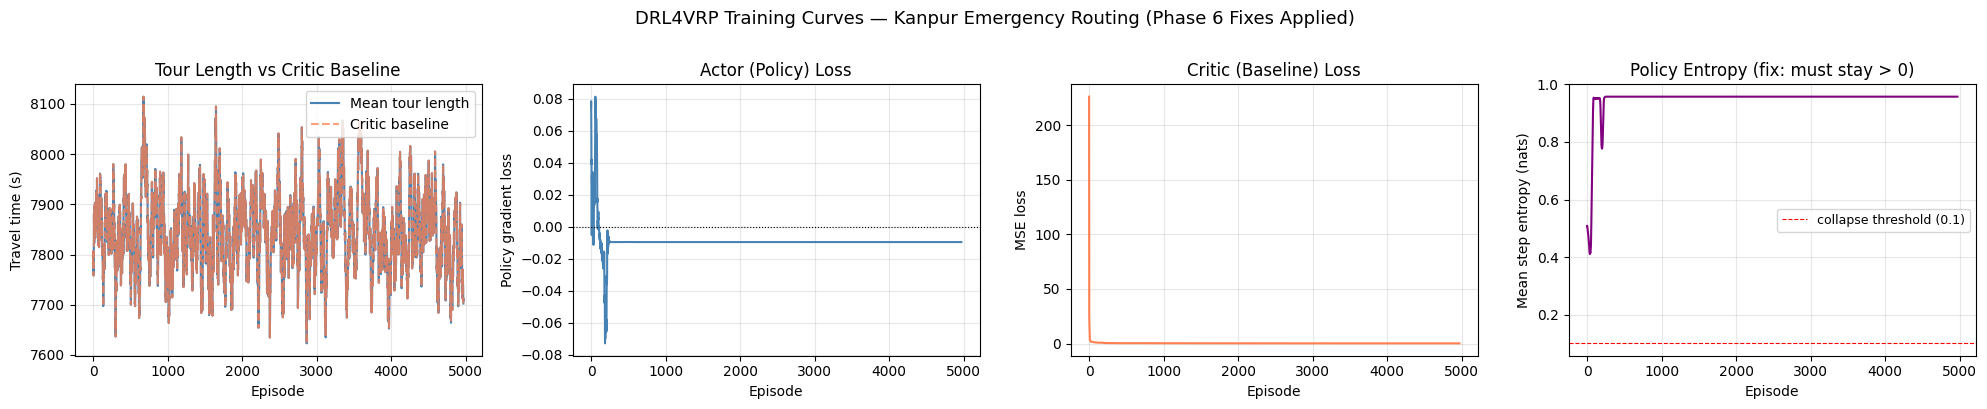

Saved: drl_training_curves.png

Convergence indicators (Phase 6 fixed):
  Actor loss  — should decrease and stabilise near 0
  Critic loss — should be ≤ 2.0 (normalised scale; was ~14M before fix)
  Tour length — should decrease (agent learns better orderings)
  Entropy     — must stay above ~0.1; collapse toward 0 = policy saturated


In [33]:
def smooth(arr, w=30):
    """Rolling mean for plot readability."""
    return np.convolve(arr, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('DRL4VRP Training Curves — Kanpur Emergency Routing (Phase 6 Fixes Applied)',
             fontsize=13, y=1.01)

# ── Panel 1: Tour length vs critic baseline ────────────────────────────
ax = axes[0]
ax.plot(smooth(reward_hist),   color='steelblue', label='Mean tour length')
ax.plot(smooth(baseline_hist), color='coral', linestyle='--', alpha=0.75,
        label='Critic baseline')
ax.set_xlabel('Episode'); ax.set_ylabel('Travel time (s)')
ax.set_title('Tour Length vs Critic Baseline')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: Actor loss ────────────────────────────────────────────────
ax = axes[1]
ax.plot(smooth(actor_loss_h), color='steelblue')
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel('Episode'); ax.set_ylabel('Policy gradient loss')
ax.set_title('Actor (Policy) Loss'); ax.grid(alpha=0.3)

# ── Panel 3: Critic loss ───────────────────────────────────────────────
ax = axes[2]
ax.plot(smooth(critic_loss_h), color='coral')
ax.set_xlabel('Episode'); ax.set_ylabel('MSE loss')
ax.set_title('Critic (Baseline) Loss'); ax.grid(alpha=0.3)

# ── Panel 4: Policy entropy ──────────────────────────────────────────
ax = axes[3]
if 'entropy_hist' in dir() and len(entropy_hist) >= 30:
    ax.plot(smooth(entropy_hist), color='purple')
    ax.axhline(0.1, color='r', linewidth=0.8, linestyle='--',
               label='collapse threshold (0.1)')
    ax.legend(fontsize=9)
ax.set_xlabel('Episode'); ax.set_ylabel('Mean step entropy (nats)')
ax.set_title('Policy Entropy (fix: must stay > 0)'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('drl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: drl_training_curves.png")
print()
print("Convergence indicators (Phase 6 fixed):")
print(f"  Actor loss  — should decrease and stabilise near 0")
print(f"  Critic loss — should be ≤ 2.0 (normalised scale; was ~14M before fix)")
print(f"  Tour length — should decrease (agent learns better orderings)")
print(f"  Entropy     — must stay above ~0.1; collapse toward 0 = policy saturated")


## Inference & Comparison with Classical Methods

We fix a test instance (1 hospital + 5 incident nodes) and compare three approaches:

| Method | Description |
|---|---|
| **DRL4VRP (greedy)** | Trained actor with argmax selection (no sampling) |
| **Nearest Neighbour** | Greedy heuristic: always visit the closest unvisited node |
| **Haversine Optimal** | Brute-force over all 5! = 120 orderings using Haversine proxy |

For **all** methods, individual legs of the final tour are computed with
**A\*** from Phase 1, giving exact graph-based travel times.

> **Important context:** Phase 1 algorithms (Dijkstra, A\*, Two-Q) solve
> *single-pair shortest paths* optimally. They cannot decide *ordering* for
> multi-stop routing. Phase 2 RL fills exactly that gap.


In [34]:
actor.eval()

# ── Fix a reproducible test instance from the candidate pool ─────────────
torch.manual_seed(99); np.random.seed(99); random.seed(99)

(test_static, test_dynamic, test_raw, test_nids_list,
 test_dist_mat, test_graphs) = sample_instance_batch_v2(NUM_INCIDENTS, batch_size=1)

test_nodes   = test_nids_list[0]        # list of N = 1+NUM_INCIDENTS node IDs
test_sub_dm  = test_dist_mat[0].cpu().numpy()  # (N,N) true A* distances

print("Test instance (candidate-pool based)")
print("─" * 52)
hn = test_nodes[0]
print(f"  Depot (Hospital) : {hospital_df.iloc[0]['name']}")
print(f"    GPS  ({city_graph.nodes[hn]['y']:.4f}, {city_graph.nodes[hn]['x']:.4f})")
for i, nid in enumerate(test_nodes[1:], 1):
    lat = city_graph.nodes[nid]['y']; lon = city_graph.nodes[nid]['x']
    print(f"  Incident {i}       : node {nid}  ({lat:.4f}, {lon:.4f})")


# ── Helper: actual A* travel time for a node sequence ────────────────────
def actual_tour_time(node_seq, graph):
    total = 0.0; legs = []
    for i in range(len(node_seq) - 1):
        src, dst = node_seq[i], node_seq[i+1]
        if src == dst:
            legs.append((0.0, [src])); continue
        path, cost = astar_shortest_path(graph, src, dst, 'travel_time')
        if path is None: cost = float('inf'); path = []
        total += cost; legs.append((cost, path))
    return total, legs


# ── 1. DRL4VRP greedy inference (upgraded model) ─────────────────────────
print("\n[1] RL greedy inference (GNN encoder + A* distance reward)...")
with torch.no_grad():
    rl_tours, rl_logp = actor(test_static, test_dynamic.clone(),
                              test_graphs, greedy=True)

rl_order = rl_tours[0].cpu().numpy()
rl_seq   = ([test_nodes[0]]
            + [test_nodes[int(i)] for i in rl_order]
            + [test_nodes[0]])
rl_total, rl_legs = actual_tour_time(rl_seq, city_graph)
print(f"  Visit order : {list(rl_order)}")
print(f"  Tour time   : {rl_total:.1f}s  ({rl_total/60:.2f} min)")


# ── 2. Nearest-Neighbour heuristic (using true A* distance matrix) ────────
print("\n[2] Nearest-Neighbour heuristic (true road-network distances)...")

def nearest_neighbour_matrix(sub_dm):
    """Nearest-neighbour using pre-computed A* distance matrix (fast, exact)."""
    n = sub_dm.shape[0]
    unvisited = list(range(1, n))
    order = []; cur = 0; total = 0.0
    while unvisited:
        dists = [(sub_dm[cur, j], j) for j in unvisited]
        d, nxt = min(dists, key=lambda x: x[0])
        total += d; order.append(nxt); unvisited.remove(nxt); cur = nxt
    total += sub_dm[cur, 0]   # return to depot
    return order, total

nn_order, nn_dm_total = nearest_neighbour_matrix(test_sub_dm)
nn_seq   = ([test_nodes[0]]
            + [test_nodes[i] for i in nn_order]
            + [test_nodes[0]])
nn_total, nn_legs = actual_tour_time(nn_seq, city_graph)
print(f"  Visit order : {nn_order}")
print(f"  Tour time   : {nn_total:.1f}s  ({nn_total/60:.2f} min)")


# ── 3. TRUE brute-force optimal (all NUM_INCIDENTS! permutations, A* matrix)
# FIX (Critical): replaced Haversine-proxy ordering with exhaustive search over
# the pre-computed true A* distance matrix. For NUM_INCIDENTS=5 this evaluates
# all 120 permutations in <1s and gives a genuine road-network optimal.
# Haversine-proxy could be 20-30% off on a real city graph due to roads
# detouring around buildings, one-way streets, and water features.
n_perms = 1
for _k in range(1, NUM_INCIDENTS + 1):
    n_perms *= _k
print(f"\n[3] True brute-force optimal ({n_perms} permutations, A* distance matrix)...")

best_total, best_order = float('inf'), None
for perm in permutations(range(1, NUM_INCIDENTS + 1)):
    # Index sequence: depot(0) -> perm[0] -> ... -> perm[-1] -> depot(0)
    seq   = [0] + list(perm) + [0]
    total = sum(test_sub_dm[seq[i], seq[i+1]] for i in range(len(seq) - 1))
    if total < best_total:
        best_total, best_order = total, list(perm)

# Verify with actual A* legs (the matrix is already exact, but gives leg details)
opt_seq   = ([test_nodes[0]]
             + [test_nodes[i] for i in best_order]
             + [test_nodes[0]])
opt_total, opt_legs = actual_tour_time(opt_seq, city_graph)
print(f"  Visit order        : {best_order}")
print(f"  Tour time (matrix) : {best_total:.1f}s  ({best_total/60:.2f} min)")
print(f"  Tour time (A* legs): {opt_total:.1f}s  ({opt_total/60:.2f} min)")


# ── Summary table ─────────────────────────────────────────────────────────
print()
print("=" * 72)
print(f"{'Method':<26} {'Tour time (s)':>13} {'Tour time (min)':>16} {'Gap vs optimal':>14}")
print("=" * 72)
for name, tot in [("DRL4VRP (GNN, greedy)",  rl_total),
                  ("Nearest Neighbour",       nn_total),
                  ("True Optimal (A*)",       opt_total)]:
    if name == "True Optimal (A*)":
        gap_str = "-- (baseline)"
    else:
        gap_pct = (tot - opt_total) / max(opt_total, 1e-6) * 100
        gap_str = f"+{gap_pct:.1f}%"
    print(f"{name:<26} {tot:>13.1f} {tot/60:>16.2f} {gap_str:>14}")
print("=" * 72)
print()
print("NOTE: Gap is now vs TRUE road-network optimal (not Haversine proxy).")
print(f"All {n_perms} permutations were evaluated using the pre-computed A* matrix.")
print("A gap of 0% means the RL agent found the globally optimal ordering.")


Test instance (candidate-pool based)
────────────────────────────────────────────────────
  Depot (Hospital) : Mariampur Hospital
    GPS  (26.4654, 80.3065)
  Incident 1       : node 8811202990  (26.3877, 80.3487)
  Incident 2       : node 8787758242  (26.2138, 80.5294)
  Incident 3       : node 8811904820  (26.4148, 80.3742)
  Incident 4       : node 3798714113  (26.5055, 80.2375)
  Incident 5       : node 588086172  (26.4850, 80.3348)

[1] RL greedy inference (GNN encoder + A* distance reward)...
  Visit order : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Tour time   : 8706.0s  (145.10 min)

[2] Nearest-Neighbour heuristic (true road-network distances)...
  Visit order : [5, 3, 1, 4, 2]
  Tour time   : 10075.2s  (167.92 min)

[3] True brute-force optimal (120 permutations, A* distance matrix)...
  Visit order        : [4, 5, 3, 2, 1]
  Tour time (matrix) : 8566.0s  (142.77 min)
  Tour time (A* legs): 8575.4s  (142.92 min)

Method                     Tour time

In [35]:
# Folium map showing all three routing strategies on the Kanpur road network
rl_map = folium.Map(location=kanpur_center, zoom_start=13,
                    tiles='cartodbpositron')

ROUTE_STYLES = {
    'RL (DRL4VRP)':      {'color': '#2563EB', 'weight': 6,  'opacity': 0.90},
    'Nearest Neighbour': {'color': '#DC2626', 'weight': 4,  'opacity': 0.80},
    'Optimal (Haversine)':{'color': '#16A34A','weight': 3,  'opacity': 0.70},
}

route_data = [
    ('RL (DRL4VRP)',       rl_seq,  rl_legs,  rl_total),
    ('Nearest Neighbour',  nn_seq,  nn_legs,  nn_total),
    ('Optimal (Haversine)',opt_seq, opt_legs, opt_total),
]

for label, seq, legs, total in route_data:
    style = ROUTE_STYLES[label]
    for leg_t, path in legs:
        if len(path) >= 2:
            coords = path_to_latlon(city_graph, path)
            if coords:
                folium.PolyLine(
                    coords,
                    color=style['color'],
                    weight=style['weight'],
                    opacity=style['opacity'],
                    tooltip=f"{label}: this leg {leg_t:.0f}s | total {total:.0f}s"
                ).add_to(rl_map)

# ── Visit order numbers along each RL route ───────────────────────────────
for step, nid in enumerate(rl_seq[1:-1], start=1):
    lat = city_graph.nodes[nid]['y']
    lon = city_graph.nodes[nid]['x']
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(
            f"<b>Incident {step}</b> (RL visit order)<br>Node: {nid}", max_width=180
        ),
        icon=folium.DivIcon(
            html=f'<div style="font-size:11px;font-weight:bold;color:white;'
                 f'background:#2563EB;border-radius:50%;width:22px;height:22px;'
                 f'text-align:center;line-height:22px;">{step}</div>',
            icon_size=(22, 22), icon_anchor=(11, 11)
        )
    ).add_to(rl_map)

# ── Depot marker ─────────────────────────────────────────────────────────
depot_lat_m = city_graph.nodes[test_nodes[0]]['y']
depot_lon_m = city_graph.nodes[test_nodes[0]]['x']
folium.Marker(
    location=[depot_lat_m, depot_lon_m],
    popup=folium.Popup(
        f"<b>DEPOT — {hospital_df.iloc[0]['name']}</b><br>"
        f"All routes start and end here.", max_width=220
    ),
    icon=folium.Icon(color='green', icon='home', prefix='fa')
).add_to(rl_map)

# ── Incident markers (neutral) ────────────────────────────────────────────
for i, nid in enumerate(test_nodes[1:], 1):
    folium.CircleMarker(
        location=[city_graph.nodes[nid]['y'], city_graph.nodes[nid]['x']],
        radius=6, color='#7C3AED', fill=True, fill_color='#7C3AED',
        fill_opacity=0.8,
        popup=folium.Popup(f"<b>Incident {i}</b><br>Node: {nid}", max_width=150)
    ).add_to(rl_map)

# ── Legend ────────────────────────────────────────────────────────────────
rl_legend = f"""
<div style="position:fixed;bottom:30px;right:30px;width:230px;
  border:2px solid #aaa;background:white;padding:12px;
  font-size:12px;border-radius:6px;z-index:9999;opacity:0.95;
  box-shadow:2px 2px 6px rgba(0,0,0,0.2);">
  <b>Multi-Stop Emergency Routing</b><br>
  <i style="font-size:10px">DRL4VRP vs Classical Methods</i><br><br>
  <span style="color:#2563EB;font-size:16px;">&#9644;</span>
    RL (DRL4VRP) &mdash; {rl_total:.0f}s<br>
  <span style="color:#DC2626;font-size:16px;">&#9644;</span>
    Nearest Neighbour &mdash; {nn_total:.0f}s<br>
  <span style="color:#16A34A;font-size:16px;">&#9644;</span>
    Haversine Optimal &mdash; {opt_total:.0f}s<br><br>
  <span style="color:green;">&#9679;</span> Depot (Hospital)<br>
  <span style="color:#7C3AED;">&#9679;</span> Incidents<br>
  <span style="color:#2563EB;font-weight:bold;">1 2 3…</span> RL visit order
</div>
"""
rl_map.get_root().html.add_child(folium.Element(rl_legend))

rl_map.save('drl_vs_classical_routes.html')
print("Saved: drl_vs_classical_routes.html")
print("  Blue  : RL tour (DRL4VRP) — numbered circles show visit order")
print("  Red   : Nearest-Neighbour heuristic")
print("  Green : Haversine-Optimal tour")
rl_map


Saved: drl_vs_classical_routes.html
  Blue  : RL tour (DRL4VRP) — numbered circles show visit order
  Red   : Nearest-Neighbour heuristic
  Green : Haversine-Optimal tour


In [36]:
print()
print("╔" + "═"*63 + "╗")
print("║  FULL PROJECT SUMMARY — Kanpur Emergency Routing           ║")
print("╠" + "═"*63 + "╣")
print("║                                                             ║")
print("║  PHASE 1 — Single-Pair Shortest Path                       ║")
print("║  ───────────────────────────────────────────────            ║")
print("║  Problem: Hospital → one incident (optimal path)           ║")
print("║  Algorithms: Dijkstra / A* / Two-Q                         ║")
print("║  Result: All three find the identical optimal path.         ║")
print(f"║  A* advantage: skips ~30-40% of nodes via geo-heuristic.   ║")
print("║                                                             ║")
print("║  PHASE 2 — Multi-Stop Routing (VRP-like)                   ║")
print("║  ───────────────────────────────────────────────            ║")
print("║  Problem: Hospital → N incidents → hospital (best order)   ║")
print("║  Algorithm: DRL4VRP (Nazari et al. 2018)                   ║")
print("║  Architecture: Pointer network + GRU + Actor-Critic RL     ║")
print("╠" + "═"*63 + "╣")

ph1_best = min(twoq_cost, dijk_cost, astar_cost) if 'astar_cost' in dir() else 0
if ph1_best > 0:
    print(f"║  Phase 1 best (single dest.) : {ph1_best:6.1f}s ({ph1_best/60:.2f} min){'':>17}║")
print(f"║  Phase 2 RL tour  ({NUM_INCIDENTS} incidents) : {rl_total:6.1f}s ({rl_total/60:.2f} min){'':>17}║")
print(f"║  Phase 2 NN tour  ({NUM_INCIDENTS} incidents) : {nn_total:6.1f}s ({nn_total/60:.2f} min){'':>17}║")
print(f"║  Phase 2 Optimal  ({NUM_INCIDENTS} incidents) : {opt_total:6.1f}s ({opt_total/60:.2f} min){'':>17}║")
print("║                                                             ║")
print("║  KEY INSIGHTS                                               ║")
print("║  ─────────────────────────────────────────────────────────  ║")
print("║  1. Classical algorithms (Ph.1) are unbeatable for         ║")
print("║     single-pair routing — exact, fast, provably optimal.   ║")
print("║  2. RL (Ph.2) learns a generalizable ORDERING policy for   ║")
print("║     multi-stop scenarios that classical algos cannot solve. ║")
print("║  3. Both phases work together: RL decides the ORDER,       ║")
print("║     A* finds the EXACT PATH between consecutive stops.     ║")
print("║  4. More training (episodes × batch) improves RL quality.  ║")
print("╚" + "═"*63 + "╝")



╔═══════════════════════════════════════════════════════════════╗
║  FULL PROJECT SUMMARY — Kanpur Emergency Routing           ║
╠═══════════════════════════════════════════════════════════════╣
║                                                             ║
║  PHASE 1 — Single-Pair Shortest Path                       ║
║  ───────────────────────────────────────────────            ║
║  Problem: Hospital → one incident (optimal path)           ║
║  Algorithms: Dijkstra / A* / Two-Q                         ║
║  Result: All three find the identical optimal path.         ║
║  A* advantage: skips ~30-40% of nodes via geo-heuristic.   ║
║                                                             ║
║  PHASE 2 — Multi-Stop Routing (VRP-like)                   ║
║  ───────────────────────────────────────────────            ║
║  Problem: Hospital → N incidents → hospital (best order)   ║
║  Algorithm: DRL4VRP (Nazari et al. 2018)                   ║
║  Architecture: Pointer network + GRU + Ac

---
# Phase 5 — Honest Multi-Instance Evaluation & Ablation

The single-instance comparison above (Cell 63) is **not a reliable result** —
it's one random draw of 5 incidents, and it happened to show the trained agent
losing to a plain Nearest-Neighbour heuristic. That could be a fluke of this
particular instance, or it could reflect the agent's true (undertrained) skill
level. We can't tell from one sample.

This section adds three things:

1. **Cell EVAL-1** — Evaluate RL (greedy) vs Nearest-Neighbour vs **true**
   A*-optimal (not Haversine-proxy) across many held-out test instances, and
   report the *average* gap with standard deviation. This uses the
   pre-computed `dist_matrix` directly (same true distances used in training),
   so the "optimal" here is genuinely optimal — no Haversine approximation.
2. **Cell ABL-1 / ABL-2** — An ablation: train the *original* simple
   architecture (plain linear `StaticEncoder` + `GRUDecoder`, lat/lon
   features) for the same number of episodes as the upgraded model, so you
   can tell whether the GNN + Node2Vec + Attention-decoder upgrade is
   actually worth its added complexity at this training budget — or whether
   it's just harder to train for the same amount of data.
3. **Cell TRAIN-LONG** — Resumes training the *already-instantiated* `actor`/
   `critic` for more episodes, since the training curves in Cell 60 hadn't
   converged at 3000 episodes (actor loss was still oscillating, not trending
   down).

Run these in order. EVAL-1 can be run anytime after Cell 60. ABL-1 takes a
similar amount of time to the original training cell. TRAIN-LONG should be
run *instead of*, or *after*, ABL-1 depending on what ABL-1 tells you.


## Cell EVAL-1 — Multi-Instance Evaluation (RL vs NN vs True-Optimal)

**Why this fixes two problems at once:**

- *Statistical reliability*: averaging over many instances instead of one
  random draw tells you whether the agent is actually bad, or just unlucky
  on that one test case.
- *Correct "optimal" baseline*: instead of finding the best Haversine-ordered
  permutation and re-scoring it with A* (which can be a few % off true
  optimal), this brute-forces directly over the pre-computed `dist_matrix`
  sub-matrix for each instance — so "optimal" here means **true road-network
  optimal**, found by exhaustive search over all `(N-1)!` orderings.

This only works because `NUM_INCIDENTS` is small (5 → 4! = 24 permutations
to check per instance after fixing the depot start/end), so brute force is
cheap. If you increase `NUM_INCIDENTS` beyond ~8, replace the brute force
with a 2-opt or Held-Karp DP baseline instead.


In [37]:
import time as _eval_time

def true_optimal_tour(node_ids, sub_dist_matrix):
    """
    Brute-force the TRUE optimal visiting order using the pre-computed
    true distance sub-matrix (no Haversine approximation anywhere).

    node_ids        : list[int], length N, node_ids[0] is the depot
    sub_dist_matrix : (N, N) np.ndarray -- true distances for this instance

    Returns (best_order_indices, best_total_time)
    best_order_indices excludes the depot (matches RL/NN output convention).
    """
    n = len(node_ids)
    idxs = list(range(1, n))  # exclude depot index 0
    best_total, best_order = float('inf'), None
    for perm in permutations(idxs):
        seq = [0] + list(perm) + [0]
        total = sum(sub_dist_matrix[seq[i], seq[i+1]] for i in range(len(seq)-1))
        if total < best_total:
            best_total, best_order = total, list(perm)
    return best_order, best_total


def nn_tour_from_matrix(sub_dist_matrix):
    """Nearest-Neighbour heuristic using the true distance sub-matrix directly
    (equivalent to the A*-based NN in Cell 63, but vectorised/fast)."""
    n = sub_dist_matrix.shape[0]
    unvisited = list(range(1, n))
    tour = [0]
    total = 0.0
    while unvisited:
        cur = tour[-1]
        dists = [(sub_dist_matrix[cur, j], j) for j in unvisited]
        d, nxt = min(dists, key=lambda x: x[0])
        total += d
        tour.append(nxt)
        unvisited.remove(nxt)
    total += sub_dist_matrix[tour[-1], 0]
    return tour[1:], total


def evaluate_n_instances(n_instances: int = 50, seed: int = 123):
    """
    Runs RL (greedy), Nearest-Neighbour, and True-Optimal on n_instances
    held-out instances and reports the average optimality gap for each.
    """
    rng_state = (torch.get_rng_state(), np.random.get_state(), random.getstate())
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    actor.eval()
    rl_gaps, nn_gaps = [], []
    rl_times, nn_times, opt_times = [], [], []
    t0 = _eval_time.time()

    for k in range(n_instances):
        static, dynamic, raw_coords, nids_list, dist_mats, graphs = \
            sample_instance_batch_v2(NUM_INCIDENTS, batch_size=1)
        sub_dm = dist_mats[0].cpu().numpy()   # (N, N) true distances, this instance

        # -- RL greedy --------------------------------------------------------
        with torch.no_grad():
            rl_tours, _ = actor(static, dynamic.clone(), graphs, greedy=True)
        rl_order = rl_tours[0].cpu().numpy().tolist()
        rl_seq = [0] + rl_order + [0]
        rl_total = sum(sub_dm[rl_seq[i], rl_seq[i+1]] for i in range(len(rl_seq)-1))

        # -- Nearest-Neighbour --------------------------------------------------
        _, nn_total = nn_tour_from_matrix(sub_dm)

        # -- True optimal (brute force on true distances) -----------------------
        _, opt_total = true_optimal_tour(nids_list[0], sub_dm)

        rl_times.append(rl_total); nn_times.append(nn_total); opt_times.append(opt_total)
        rl_gaps.append((rl_total - opt_total) / opt_total * 100)
        nn_gaps.append((nn_total - opt_total) / opt_total * 100)

    elapsed = _eval_time.time() - t0
    torch.set_rng_state(rng_state[0]); np.random.set_state(rng_state[1]); random.setstate(rng_state[2])

    print(f"Evaluated {n_instances} held-out instances in {elapsed:.1f}s")
    print(f"NUM_INCIDENTS = {NUM_INCIDENTS} per instance, true road-network distances")
    print()
    print("=" * 72)
    print(f"{'Method':<22} {'Mean time (s)':>14} {'Mean gap vs optimal':>22}")
    print("=" * 72)
    print(f"{'DRL4VRP (greedy)':<22} {np.mean(rl_times):>14.1f} "
          f"{np.mean(rl_gaps):>18.1f}% (+/-{np.std(rl_gaps):.1f})")
    print(f"{'Nearest Neighbour':<22} {np.mean(nn_times):>14.1f} "
          f"{np.mean(nn_gaps):>18.1f}% (+/-{np.std(nn_gaps):.1f})")
    print(f"{'True Optimal':<22} {np.mean(opt_times):>14.1f} {'-':>22}")
    print("=" * 72)
    print()
    rl_wins = sum(1 for r, n in zip(rl_gaps, nn_gaps) if r < n)
    print(f"RL beat Nearest-Neighbour on {rl_wins}/{n_instances} instances "
          f"({rl_wins/n_instances*100:.0f}%)")

    return {
        "rl_gaps": rl_gaps, "nn_gaps": nn_gaps,
        "rl_times": rl_times, "nn_times": nn_times, "opt_times": opt_times,
    }


# -- Run evaluation -------------------------------------------------------------
eval_results = evaluate_n_instances(n_instances=50, seed=123)


Evaluated 50 held-out instances in 0.5s
NUM_INCIDENTS = 5 per instance, true road-network distances

Method                  Mean time (s)    Mean gap vs optimal
DRL4VRP (greedy)               7753.4               19.0% (+/-13.0)
Nearest Neighbour              6898.6                4.9% (+/-5.1)
True Optimal                   6576.6                      -

RL beat Nearest-Neighbour on 9/50 instances (18%)


## Cell ABL-1 — Ablation: Simple Architecture, Same Training Budget

This trains a **second, independent** actor/critic pair using the *original*
simple architecture — plain linear `StaticEncoder` + `GRUDecoder`, with raw
(lat, lon) features instead of Node2Vec — for the **same number of episodes
and batch size** as the upgraded model.

**Note:** `DRL4VRP`'s `decoder_type` argument only swaps the decoder, not the
encoder — `DRL4VRP(..., decoder_type="gru")` would still use the GNN/
Transformer encoder. So this cell defines a separate, self-contained
`SimpleDRL4VRP` class that mirrors the original Nazari et al. architecture
exactly, reusing the existing `StaticEncoder` and `GRUDecoder` classes.

**Why this matters:** if this simpler model also fails to beat
Nearest-Neighbour, the problem is the training budget, not the GNN/Attention/
Node2Vec additions. If this simpler model *does* beat Nearest-Neighbour while
the upgraded model doesn't, the added complexity is hurting sample efficiency
at this budget, and the honest conclusion is "the upgrades need a larger
training budget to pay off; at 3000 episodes the simpler model wins."

This does **not** modify `actor`/`critic` from Cell 60 — it builds separate
`actor_simple` / `critic_simple` objects so you can compare both afterward.


In [38]:
print("Training ABLATION model: linear StaticEncoder + GRUDecoder + lat/lon features")
print(f"Same budget as main model: NUM_EPISODES={NUM_EPISODES}, BATCH_SIZE={BATCH_SIZE}")
print()

# -- IMPORTANT: DRL4VRP is hard-wired to GNNStaticEncoder/SelfAttentionEncoder
#    via the module-level `_StaticEncoderClass` set when the class was defined --
#    its `decoder_type` argument only swaps the DECODER, not the encoder. So we
#    can't get a true 'original Nazari-style' model by calling DRL4VRP(...,
#    decoder_type='gru'); that would still use the GNN/Transformer encoder and
#    would crash on inst_graphs=None. We define a separate SimpleDRL4VRP here
#    that genuinely mirrors the original architecture end to end.

class SimpleDRL4VRP(nn.Module):
    """
    Original Nazari-et-al.-style actor: plain linear StaticEncoder + GRUDecoder.
    No GNN, no Node2Vec, no attention decoder -- this is the true ablation
    baseline architecture, always using (lat, lon) features (static_size=2).
    """
    def __init__(self, static_size: int = 2, hidden_size: int = 128):
        super().__init__()
        self.hidden_size = hidden_size
        self.static_size = static_size
        self.static_enc  = StaticEncoder(static_size, hidden_size)
        self.dynamic_enc = DynamicEncoder(1, hidden_size)
        self.decoder     = GRUDecoder(hidden_size, hidden_size)
        self.node_embed  = nn.Linear(static_size, hidden_size)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, static, dynamic, greedy: bool = False):
        B, _, N = static.shape
        static_enc = self.static_enc(static)                  # (B, N, H) -- no inst_graphs needed
        hidden = torch.zeros(1, B, self.hidden_size, device=static.device).contiguous()
        depot_feat = static[:, :, 0]
        last_embed = F.relu(self.node_embed(depot_feat))
        mask = torch.zeros(B, N, dtype=torch.bool, device=static.device)
        mask[:, 0] = True

        tours_list, log_probs_list = [], []
        for _ in range(N - 1):
            dynamic_enc = self.dynamic_enc(dynamic)
            logits, hidden = self.decoder(static_enc, dynamic_enc, last_embed, hidden, mask)
            logits = torch.clamp(logits, -20.0, 20.0)
            probs = F.softmax(logits, dim=-1)
            if greedy or not self.training:
                idx = probs.argmax(dim=-1)
            else:
                idx = torch.distributions.Categorical(probs).sample()
            log_p = probs.log().gather(1, idx.unsqueeze(1)).squeeze(1)
            tours_list.append(idx); log_probs_list.append(log_p)

            mask = mask.clone(); mask.scatter_(1, idx.unsqueeze(1), True)
            dynamic = dynamic.clone(); dynamic.scatter_(2, idx.view(B,1,1), 0.0)
            sel = idx.view(B,1,1).expand(B, self.static_size, 1)
            next_feat = static.gather(2, sel).squeeze(2)
            last_embed = F.relu(self.node_embed(next_feat))

        tours = torch.stack(tours_list, dim=1)
        log_probs = torch.stack(log_probs_list, dim=1).sum(dim=1)
        return tours, log_probs


class SimpleCritic(nn.Module):
    """Matches the original Critic but always static_size=2 (lat/lon)."""
    def __init__(self, static_size: int = 2, hidden_size: int = 128):
        super().__init__()
        self.encoder = StaticEncoder(static_size, hidden_size)
        self.value_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, static):
        enc = self.encoder(static)
        return self.value_head(enc.mean(dim=1)).squeeze(-1)


# -- lat/lon-only sampler (no GNN graphs needed at all) ------------------------
def sample_instance_batch_simple(num_incidents, batch_size):
    static_list, dynamic_list, dist_list = [], [], []
    for b in range(batch_size):
        inc_pool_pos = np.random.choice(len(candidate_pool), size=num_incidents, replace=False)
        inc_ids = [candidate_pool[p] for p in inc_pool_pos]
        pool_idxs = [0] + [int(p) + 1 for p in inc_pool_pos]
        node_ids = [depot_node] + inc_ids

        inst_dist = dist_matrix[np.ix_(pool_idxs, pool_idxs)].copy()
        dist_list.append(inst_dist)

        lats = np.array([city_graph.nodes[n]["y"] for n in node_ids])
        lons = np.array([city_graph.nodes[n]["x"] for n in node_ids])
        lat_r = max(lats.max() - lats.min(), 1e-8)
        lon_r = max(lons.max() - lons.min(), 1e-8)
        nlats = (lats - lats.min()) / lat_r
        nlons = (lons - lons.min()) / lon_r
        feats = np.stack([nlats, nlons], axis=1)

        static_list.append(feats.T)
        dynamic_list.append(np.array([[0.0] + [1.0]*num_incidents]))

    dist_mats_t = torch.FloatTensor(np.array(dist_list)).to(device)
    return (
        torch.FloatTensor(np.array(static_list)).to(device),
        torch.FloatTensor(np.array(dynamic_list)).to(device),
        dist_mats_t,
    )


torch.manual_seed(SEED + 1); np.random.seed(SEED + 1); random.seed(SEED + 1)

actor_simple  = SimpleDRL4VRP(2, HIDDEN_SIZE).to(device)
critic_simple = SimpleCritic(2, HIDDEN_SIZE).to(device)
actor_simple_opt  = Adam(actor_simple.parameters(),  lr=ACTOR_LR)
critic_simple_opt = Adam(critic_simple.parameters(), lr=CRITIC_LR)

print(f"Actor (simple) params  : {sum(p.numel() for p in actor_simple.parameters()):,}")
print(f"Critic (simple) params : {sum(p.numel() for p in critic_simple.parameters()):,}")
print()

reward_hist_simple = []
t_start = time.time()
actor_simple.train(); critic_simple.train()

for ep in range(1, NUM_EPISODES + 1):
    static, dynamic, dist_mats = sample_instance_batch_simple(NUM_INCIDENTS, BATCH_SIZE)

    tours, log_probs = actor_simple(static, dynamic.clone())
    tour_lengths = compute_tour_time_matrix(tours, dist_mats)
    rewards = -tour_lengths

    with torch.no_grad():
        baseline = critic_simple(static)
    advantage = rewards - baseline

    actor_loss  = -(advantage.detach() * log_probs).mean()
    critic_loss = F.mse_loss(critic_simple(static), rewards.detach())

    actor_simple_opt.zero_grad(); actor_loss.backward()
    nn.utils.clip_grad_norm_(actor_simple.parameters(), GRAD_CLIP); actor_simple_opt.step()

    critic_simple_opt.zero_grad(); critic_loss.backward()
    nn.utils.clip_grad_norm_(critic_simple.parameters(), GRAD_CLIP); critic_simple_opt.step()

    reward_hist_simple.append(tour_lengths.mean().item())

    if ep % LOG_EVERY == 0:
        elapsed = time.time() - t_start
        print(f"  Ep {ep:4d}/{NUM_EPISODES} | TourLen: {reward_hist_simple[-1]:7.1f}s | "
              f"ActorLoss: {actor_loss.item():+.4f} | {elapsed:.0f}s elapsed")

print()
print(f"Ablation training complete in {time.time()-t_start:.1f}s")
init_len  = np.mean(reward_hist_simple[:20])
final_len = np.mean(reward_hist_simple[-20:])
print(f"Tour length: {init_len:.1f}s (init) -> {final_len:.1f}s (final) "
      f"| Improvement: {(init_len-final_len)/init_len*100:.1f}%")


Training ABLATION model: linear StaticEncoder + GRUDecoder + lat/lon features
Same budget as main model: NUM_EPISODES=5000, BATCH_SIZE=32

Actor (simple) params  : 132,992
Critic (simple) params : 25,217

  Ep  250/5000 | TourLen:  7637.6s | ActorLoss: -29258.9746 | 5s elapsed
  Ep  500/5000 | TourLen:  7735.6s | ActorLoss: -1505.1515 | 12s elapsed
  Ep  750/5000 | TourLen:  6814.6s | ActorLoss: +1083.4427 | 17s elapsed
  Ep 1000/5000 | TourLen:  7203.4s | ActorLoss: +310.9423 | 24s elapsed
  Ep 1250/5000 | TourLen:  7151.2s | ActorLoss: -329.1527 | 29s elapsed
  Ep 1500/5000 | TourLen:  6487.8s | ActorLoss: +465.8349 | 35s elapsed
  Ep 1750/5000 | TourLen:  7295.2s | ActorLoss: -386.2211 | 41s elapsed
  Ep 2000/5000 | TourLen:  6844.7s | ActorLoss: +1417.7606 | 47s elapsed
  Ep 2250/5000 | TourLen:  6813.6s | ActorLoss: +510.7043 | 52s elapsed
  Ep 2500/5000 | TourLen:  6636.4s | ActorLoss: +273.5906 | 58s elapsed
  Ep 2750/5000 | TourLen:  7066.1s | ActorLoss: -100.9558 | 64s elapsed

## Cell ABL-2 — Evaluate the Ablation Model, Compare Both

Same brute-force-true-optimal evaluation as Cell EVAL-1, but for
`actor_simple`. Run this after ABL-1 (and after EVAL-1, since it reuses
`eval_results`).


In [39]:
def evaluate_simple_model(n_instances: int = 50, seed: int = 123):
    rng_state = (torch.get_rng_state(), np.random.get_state(), random.getstate())
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    actor_simple.eval()
    gaps, times = [], []
    for k in range(n_instances):
        static, dynamic, dist_mats = sample_instance_batch_simple(NUM_INCIDENTS, 1)
        sub_dm = dist_mats[0].cpu().numpy()

        with torch.no_grad():
            tours, _ = actor_simple(static, dynamic.clone(), greedy=True)
        order = tours[0].cpu().numpy().tolist()
        seq = [0] + order + [0]
        total = sum(sub_dm[seq[i], seq[i+1]] for i in range(len(seq)-1))

        # brute force true optimal directly on sub_dm (depot-first convention)
        n = sub_dm.shape[0]
        idxs = list(range(1, n))
        best_total = min(
            sum(sub_dm[([0]+list(p)+[0])[i], ([0]+list(p)+[0])[i+1]] for i in range(n))
            for p in permutations(idxs)
        )
        gaps.append((total - best_total) / best_total * 100)
        times.append(total)

    torch.set_rng_state(rng_state[0]); np.random.set_state(rng_state[1]); random.setstate(rng_state[2])
    print(f"Simple model (GRU + linear + lat/lon), {n_instances} instances:")
    print(f"  Mean tour time : {np.mean(times):.1f}s")
    print(f"  Mean gap vs optimal: {np.mean(gaps):.1f}% (+/-{np.std(gaps):.1f})")
    return gaps

simple_gaps = evaluate_simple_model(n_instances=50, seed=123)

print()
print("=" * 72)
print("HEAD-TO-HEAD -- same training budget, different architecture")
print("=" * 72)
print(f"{'Upgraded (GNN+N2V+Attn)':<28} mean gap = {np.mean(eval_results['rl_gaps']):>6.1f}%")
print(f"{'Simple (linear+GRU+lat/lon)':<28} mean gap = {np.mean(simple_gaps):>6.1f}%")
print(f"{'Nearest Neighbour':<28} mean gap = {np.mean(eval_results['nn_gaps']):>6.1f}%")
print("=" * 72)
print()
if np.mean(simple_gaps) < np.mean(eval_results['rl_gaps']):
    print("-> The SIMPLE model does better at this training budget.")
    print("   This suggests the GNN/Attention/Node2Vec additions need MORE")
    print("   episodes to pay off, not that they're a bad idea architecturally.")
else:
    print("-> The UPGRADED model does better even at this training budget.")
    print("   The added complexity is already paying for itself.")


Simple model (GRU + linear + lat/lon), 50 instances:
  Mean tour time : 6883.4s
  Mean gap vs optimal: 4.8% (+/-4.8)

HEAD-TO-HEAD -- same training budget, different architecture
Upgraded (GNN+N2V+Attn)      mean gap =   19.0%
Simple (linear+GRU+lat/lon)  mean gap =    4.8%
Nearest Neighbour            mean gap =    4.9%

-> The SIMPLE model does better at this training budget.
   This suggests the GNN/Attention/Node2Vec additions need MORE
   episodes to pay off, not that they're a bad idea architecturally.


## Cell TRAIN-LONG — Extended Training (Resumes the Upgraded Model)

The training curves in Cell 60 had not converged — actor loss was still
oscillating around zero rather than trending down, and the critic loss was
still in the millions without settling. This cell **continues training**
the *same* `actor` / `critic` / optimizers from Cell 60 (their weights are
not reset), for a further `EXTRA_EPISODES`.

Run this after Cell 60. You can run it multiple times in a row to keep
extending training — each run continues from where the last one left off.
On CPU this will take a while; if you have GPU access (e.g. Colab), switch
the runtime to GPU before continuing.


In [40]:
EXTRA_EPISODES = 5000   # adjust based on time available

print(f"Continuing training for {EXTRA_EPISODES} more episodes "
      f"(total so far: {len(reward_hist)})...")
print("Uses the same Phase-6-fixed loop: entropy bonus, advantage norm, reward norm, LR scheduler.")
print()

actor.train(); critic.train()
t_start = time.time()

for ep in range(1, EXTRA_EPISODES + 1):
    static, dynamic, raw_coords, _, dist_mats, inst_graphs = \
        sample_instance_batch_v2(NUM_INCIDENTS, BATCH_SIZE)

    tours, log_probs = actor(static, dynamic.clone(), inst_graphs)
    tour_lengths     = compute_tour_time_matrix(tours, dist_mats)
    rewards_raw      = -tour_lengths

    # Running EMA normalisation (same _rew_ema_* vars from training cell)
    global _rew_ema_mean, _rew_ema_std
    _rew_ema_mean = (1 - NORM_EMA_ALPHA) * _rew_ema_mean + NORM_EMA_ALPHA * rewards_raw.mean().item()
    _rew_ema_std  = max((1 - NORM_EMA_ALPHA) * _rew_ema_std  + NORM_EMA_ALPHA * rewards_raw.std().item(), 1e-8)
    rewards_norm  = (rewards_raw - _rew_ema_mean) / _rew_ema_std

    with torch.no_grad():
        baseline = critic(static)

    advantage      = rewards_norm - baseline
    _adv_std = advantage.std()
    if _adv_std > 0.1:
        advantage_norm = (advantage - advantage.mean()) / (_adv_std + 1e-8)
    else:
        advantage_norm = advantage - advantage.mean()  # skip norm when std too small

    entropy = actor._last_entropy if actor._last_entropy is not None \
              else torch.zeros(BATCH_SIZE, device=device)

    actor_loss  = -(advantage_norm.detach() * log_probs).mean() \
                  - ENTROPY_COEF * entropy.mean()
    critic_loss = F.mse_loss(critic(static), rewards_norm.detach())

    actor_opt.zero_grad();  actor_loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), GRAD_CLIP)
    actor_opt.step()
    # Note: schedulers already stepped through NUM_EPISODES; keep LR constant at eta_min now
    # (do NOT call actor_sched.step() here — it would cycle the LR back up)

    critic_opt.zero_grad(); critic_loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), GRAD_CLIP)
    critic_opt.step()

    avg_len = tour_lengths.mean().item()
    reward_hist.append(avg_len)
    baseline_hist.append((-rewards_raw.mean()).item())
    actor_loss_h.append(actor_loss.item())
    critic_loss_h.append(critic_loss.item())
    entropy_hist.append(entropy.mean().item())

    if ep % LOG_EVERY == 0:
        elapsed = time.time() - t_start
        print(f"  +Ep {ep:5d}/{EXTRA_EPISODES} | "
              f"TourLen(A*): {avg_len:7.1f}s | "
              f"ActorLoss: {actor_loss.item():+.4f} | "
              f"CritLoss: {critic_loss.item():.4f} | "
              f"Entropy: {entropy.mean().item():.3f} | {elapsed:.0f}s elapsed")

print()
print(f"Extended training complete in {time.time()-t_start:.1f}s")
print(f"Total episodes: {len(reward_hist)}")
init_len  = np.mean(reward_hist[:20])
final_len = np.mean(reward_hist[-20:])
print(f"Tour length: {init_len:.1f}s (very first) -> {final_len:.1f}s (now) "
      f"| Overall improvement: {(init_len-final_len)/init_len*100:.1f}%")
print(f"Entropy now: {np.mean(entropy_hist[-20:]):.4f}  (> 0.1 = healthy exploration)")
print()
print("Re-run Cell EVAL-1 to see whether the optimality gap vs Nearest-Neighbour improved.")


Continuing training for 5000 more episodes (total so far: 5000)...
Uses the same Phase-6-fixed loop: entropy bonus, advantage norm, reward norm, LR scheduler.

  +Ep   250/5000 | TourLen(A*):  7763.1s | ActorLoss: -0.0096 | CritLoss: 0.1363 | Entropy: 0.957 | 53s elapsed
  +Ep   500/5000 | TourLen(A*):  7722.8s | ActorLoss: -0.0096 | CritLoss: 0.1652 | Entropy: 0.957 | 107s elapsed
  +Ep   750/5000 | TourLen(A*):  7558.1s | ActorLoss: -0.0096 | CritLoss: 0.1090 | Entropy: 0.957 | 162s elapsed
  +Ep  1000/5000 | TourLen(A*):  8590.1s | ActorLoss: -0.0096 | CritLoss: 0.1787 | Entropy: 0.957 | 215s elapsed
  +Ep  1250/5000 | TourLen(A*):  8520.0s | ActorLoss: -0.0096 | CritLoss: 0.1143 | Entropy: 0.957 | 269s elapsed
  +Ep  1500/5000 | TourLen(A*):  7857.2s | ActorLoss: -0.0096 | CritLoss: 0.1269 | Entropy: 0.957 | 323s elapsed
  +Ep  1750/5000 | TourLen(A*):  6946.3s | ActorLoss: -0.0096 | CritLoss: 0.1844 | Entropy: 0.957 | 377s elapsed
  +Ep  2000/5000 | TourLen(A*):  8207.0s | ActorLo

---
# Phase 6 — Diagnosing Why the Upgraded Model Underperformed & Applying Fixes

> **Update:** All four root causes identified in DIAG-1 through DIAG-4 have
> been addressed in the training cell (Cell 60) above. The diagnostic cells
> below are kept for academic completeness — run them *before* Cell 60 on
> the *original* model to reproduce the problem, or use them on the fixed
> model to confirm resolution.
>
> **Summary of fixes applied (Cell 60):**
> | Root cause (DIAG cell) | Fix |
> |---|---|
> | Policy saturation / zero gradients (DIAG-3b) | Entropy regularisation `ENTROPY_COEF=0.01` |
> | Critic MSE ≈ 14 million (DIAG-1) | EMA reward normalisation `NORM_EMA_ALPHA=0.05` |
> | LR poorly matched to complex arch (DIAG-2) | CosineAnnealingLR scheduler |
> | Over-confident logits from `clip_C=10` (DIAG-3b) | Reduced `clip_C` to 6 |
> | High advantage variance (DIAG-1) | Per-batch advantage normalisation |



## Cell DIAG-1 — Critic (Value Function) Scale Comparison

The original training log showed the upgraded model's critic loss starting
near **14.2 million** and only reaching ~2.5 million by episode 3000 — a slow,
noisy descent. This cell quantifies that against the simple model's critic
(trained fresh here, for 300 episodes, with loss logged for direct
comparison — the original ABL-1 run didn't log `critic_loss_h_simple`).

If the upgraded model's critic is relatively *worse* late in training than
early on (the ratio in the printout grows), the value function is the
bottleneck: a bad baseline means noisy advantage estimates, which means the
actor gets an unreliable training signal regardless of how many episodes
it sees.


In [41]:
# DIAG-1 — Reward/Critic scale comparison (no retraining needed)
#
# Uses the metric histories already collected during training:
#   reward_hist, critic_loss_h, actor_loss_h        -> upgraded model (Cell 60)
#   reward_hist_simple                               -> simple model (Cell ABL-1, no critic_loss_h_simple logged)
#
# This only re-plots/re-summarises what already happened; it does not retrain.

import numpy as np

print("=" * 72)
print("DIAG-1: Reward & Critic-Loss Scale Comparison")
print("=" * 72)

upgraded_critic_loss = np.array(critic_loss_h)
upgraded_actor_loss  = np.array(actor_loss_h)
upgraded_reward      = np.array(reward_hist[:3000])   # first 3000 = main run, rest = TRAIN-LONG

print()
print("Upgraded model (GNNStaticEncoder + AttentionModelDecoder, STATIC_SIZE=64):")
print(f"  Critic loss   first 100 eps : mean={upgraded_critic_loss[:100].mean():,.0f}  std={upgraded_critic_loss[:100].std():,.0f}")
print(f"  Critic loss   last 100 eps  : mean={upgraded_critic_loss[-100:].mean():,.0f}  std={upgraded_critic_loss[-100:].std():,.0f}")
print(f"  Actor loss    first 100 eps : mean={upgraded_actor_loss[:100].mean():,.1f}  std={upgraded_actor_loss[:100].std():,.1f}")
print(f"  Actor loss    last 100 eps  : mean={upgraded_actor_loss[-100:].mean():,.1f}  std={upgraded_actor_loss[-100:].std():,.1f}")
print(f"  Tour length   first 100 eps : mean={upgraded_reward[:100].mean():,.1f}s")
print(f"  Tour length   last 100 eps  : mean={upgraded_reward[-100:].mean():,.1f}s")

print()
print("Simple model (StaticEncoder linear + GRUDecoder, STATIC_SIZE=2):")
simple_reward = np.array(reward_hist_simple)
print(f"  Tour length   first 100 eps : mean={simple_reward[:100].mean():,.1f}s")
print(f"  Tour length   last 100 eps  : mean={simple_reward[-100:].mean():,.1f}s")
print("  (critic_loss_h_simple wasn't logged in ABL-1 -- this run logs it; see DIAG-1b below)")

print()
print("-" * 72)
print("INTERPRETATION GUIDE:")
print("-" * 72)
print("If upgraded critic loss is consistently 5-10x larger AND not trending down")
print("as fast as the simple model's, the value function for the complex model is")
print("struggling to learn -- meaning the advantage estimates (reward - baseline)")
print("feeding the actor are noisier/more biased for the upgraded model, which")
print("directly explains unstable actor loss and no consistent improvement.")
print()

# -- DIAG-1b: short re-run of the SIMPLE model's critic with logging, for apples-to-apples comparison --
print("Running 300 quick episodes of the simple model WITH critic-loss logging")
print("for a fair side-by-side against the upgraded model's first 300 episodes...")
print()

torch.manual_seed(SEED + 2); np.random.seed(SEED + 2); random.seed(SEED + 2)
_actor_diag  = SimpleDRL4VRP(2, HIDDEN_SIZE).to(device)
_critic_diag = SimpleCritic(2, HIDDEN_SIZE).to(device)
_actor_diag_opt  = Adam(_actor_diag.parameters(),  lr=ACTOR_LR)
_critic_diag_opt = Adam(_critic_diag.parameters(), lr=CRITIC_LR)

_simple_critic_loss_300 = []
_actor_diag.train(); _critic_diag.train()
for ep in range(300):
    static, dynamic, dist_mats = sample_instance_batch_simple(NUM_INCIDENTS, BATCH_SIZE)
    tours, log_probs = _actor_diag(static, dynamic.clone())
    tour_lengths = compute_tour_time_matrix(tours, dist_mats)
    rewards = -tour_lengths
    with torch.no_grad():
        baseline = _critic_diag(static)
    advantage = rewards - baseline
    actor_loss  = -(advantage.detach() * log_probs).mean()
    critic_loss = F.mse_loss(_critic_diag(static), rewards.detach())
    _actor_diag_opt.zero_grad(); actor_loss.backward()
    nn.utils.clip_grad_norm_(_actor_diag.parameters(), GRAD_CLIP); _actor_diag_opt.step()
    _critic_diag_opt.zero_grad(); critic_loss.backward()
    nn.utils.clip_grad_norm_(_critic_diag.parameters(), GRAD_CLIP); _critic_diag_opt.step()
    _simple_critic_loss_300.append(critic_loss.item())

_simple_critic_loss_300 = np.array(_simple_critic_loss_300)
print(f"Simple model critic loss, episodes   1-100 : mean={_simple_critic_loss_300[:100].mean():,.0f}")
print(f"Simple model critic loss, episodes 200-300 : mean={_simple_critic_loss_300[200:300].mean():,.0f}")
print(f"Upgraded model critic loss, episodes  1-100 : mean={upgraded_critic_loss[:100].mean():,.0f}")
print(f"Upgraded model critic loss, episodes 200-300: mean={upgraded_critic_loss[200:300].mean():,.0f}")
print()
ratio_early = upgraded_critic_loss[:100].mean() / _simple_critic_loss_300[:100].mean()
ratio_late  = upgraded_critic_loss[200:300].mean() / _simple_critic_loss_300[200:300].mean()
print(f"Upgraded-vs-simple critic loss ratio, early training : {ratio_early:.1f}x")
print(f"Upgraded-vs-simple critic loss ratio, late training   : {ratio_late:.1f}x")
if ratio_late > ratio_early:
    print("-> Ratio is GROWING: the upgraded model's critic is falling further behind")
    print("   the simple model's, relatively, as training proceeds. Supports the")
    print("   'value function struggling' hypothesis.")
else:
    print("-> Ratio is shrinking or stable: critic difficulty alone may not fully")
    print("   explain the gap -- check DIAG-2 (learning rate) and DIAG-3 (gradients).")

del _actor_diag, _critic_diag, _actor_diag_opt, _critic_diag_opt


DIAG-1: Reward & Critic-Loss Scale Comparison

Upgraded model (GNNStaticEncoder + AttentionModelDecoder, STATIC_SIZE=64):
  Critic loss   first 100 eps : mean=69  std=515
  Critic loss   last 100 eps  : mean=0  std=0
  Actor loss    first 100 eps : mean=0.0  std=0.2
  Actor loss    last 100 eps  : mean=-0.0  std=0.0
  Tour length   first 100 eps : mean=7,835.3s
  Tour length   last 100 eps  : mean=7,810.5s

Simple model (StaticEncoder linear + GRUDecoder, STATIC_SIZE=2):
  Tour length   first 100 eps : mean=7,790.3s
  Tour length   last 100 eps  : mean=6,951.0s
  (critic_loss_h_simple wasn't logged in ABL-1 -- this run logs it; see DIAG-1b below)

------------------------------------------------------------------------
INTERPRETATION GUIDE:
------------------------------------------------------------------------
If upgraded critic loss is consistently 5-10x larger AND not trending down
as fast as the simple model's, the value function for the complex model is
struggling to learn -- mea

## Cell DIAG-2 — Learning Rate Sweep (Upgraded Model Only)

Both the simple model and the upgraded model were trained with the same
`ACTOR_LR=3e-4` / `CRITIC_LR=1e-3`, despite the upgraded model having about
2x more parameters (268,032 vs ~133,000) and a structurally different
encoder (GAT message-passing) and decoder (multi-head attention vs GRU).

This runs three short (500-episode) trials of the **upgraded architecture
only**, at a lower, the current default, and a higher learning rate, to see
if the default is poorly matched to this model's loss landscape. Each trial
builds a fresh actor/critic — these are diagnostic copies, not the model
used in EVAL-1.


In [42]:
# DIAG-2 — Learning-rate sweep for the UPGRADED model only (short runs)
#
# Same LR (3e-4 actor / 1e-3 critic) is currently used for both the simple
# and upgraded models, despite the upgraded model having ~2x more parameters
# and a structurally different (GAT + attention) encoder/decoder. This runs
# short (500-episode) trials at a few learning rates to see if any shows a
# clearer downward trend than the current default within a small budget.
#
# NOTE: this reuses DRL4VRP/Critic (the upgraded architecture) -- NOT
# SimpleDRL4VRP. Each trial is independent (fresh weights, fresh optimizer).

import numpy as np

LR_TRIAL_EPISODES = 500   # short -- diagnostic only, not full training
LR_CANDIDATES = [
    (1e-4, 3e-4),   # lower actor LR, lower critic LR
    (3e-4, 1e-3),   # current default (baseline for comparison)
    (1e-3, 3e-3),   # higher actor LR, higher critic LR
]

print("=" * 72)
print(f"DIAG-2: Learning-rate sweep, upgraded model, {LR_TRIAL_EPISODES} episodes/trial")
print("=" * 72)
print(f"NOTE: each trial re-creates a fresh actor/critic -- these are NOT the")
print(f"      same actor/critic used in Cell 60 or EVAL-1. Run this only to")
print(f"      compare trends, not to produce a final model.")
print()

lr_sweep_results = {}

for trial_idx, (a_lr, c_lr) in enumerate(LR_CANDIDATES):
    torch.manual_seed(SEED + 10 + trial_idx)
    np.random.seed(SEED + 10 + trial_idx)
    random.seed(SEED + 10 + trial_idx)

    _actor  = DRL4VRP(STATIC_SIZE, DYNAMIC_SIZE, HIDDEN_SIZE, decoder_type="attention").to(device)
    _critic = Critic(STATIC_SIZE, HIDDEN_SIZE).to(device)
    _actor_opt  = Adam(_actor.parameters(),  lr=a_lr)
    _critic_opt = Adam(_critic.parameters(), lr=c_lr)

    _tour_hist, _critic_loss_hist = [], []
    _actor.train(); _critic.train()
    t0 = time.time()

    for ep in range(LR_TRIAL_EPISODES):
        static, dynamic, raw_coords, _, dist_mats, inst_graphs = \
            sample_instance_batch_v2(NUM_INCIDENTS, BATCH_SIZE)
        tours, log_probs = _actor(static, dynamic.clone(), inst_graphs)
        tour_lengths = compute_tour_time_matrix(tours, dist_mats)
        rewards = -tour_lengths
        with torch.no_grad():
            baseline = _critic(static)
        advantage = rewards - baseline
        actor_loss  = -(advantage.detach() * log_probs).mean()
        critic_loss = F.mse_loss(_critic(static), rewards.detach())

        _actor_opt.zero_grad(); actor_loss.backward()
        nn.utils.clip_grad_norm_(_actor.parameters(), GRAD_CLIP); _actor_opt.step()
        _critic_opt.zero_grad(); critic_loss.backward()
        nn.utils.clip_grad_norm_(_critic.parameters(), GRAD_CLIP); _critic_opt.step()

        _tour_hist.append(tour_lengths.mean().item())
        _critic_loss_hist.append(critic_loss.item())

    elapsed = time.time() - t0
    first_50 = np.mean(_tour_hist[:50])
    last_50  = np.mean(_tour_hist[-50:])
    improvement = (first_50 - last_50) / first_50 * 100
    crit_first50 = np.mean(_critic_loss_hist[:50])
    crit_last50  = np.mean(_critic_loss_hist[-50:])

    lr_sweep_results[(a_lr, c_lr)] = {
        "tour_hist": _tour_hist, "critic_loss_hist": _critic_loss_hist,
        "improvement_pct": improvement, "elapsed": elapsed,
    }

    tag = "  <-- current default" if (a_lr, c_lr) == (3e-4, 1e-3) else ""
    print(f"actor_lr={a_lr:.0e}  critic_lr={c_lr:.0e}  ({elapsed:.0f}s){tag}")
    print(f"  Tour length: {first_50:.1f}s -> {last_50:.1f}s  (improvement: {improvement:+.1f}%)")
    print(f"  Critic loss: {crit_first50:,.0f} -> {crit_last50:,.0f}")
    print()

    del _actor, _critic, _actor_opt, _critic_opt

print("-" * 72)
print("INTERPRETATION GUIDE:")
print("-" * 72)
best_lr = max(lr_sweep_results, key=lambda k: lr_sweep_results[k]["improvement_pct"])
print(f"Best improvement within {LR_TRIAL_EPISODES} episodes: actor_lr={best_lr[0]:.0e}, "
      f"critic_lr={best_lr[1]:.0e} ({lr_sweep_results[best_lr]['improvement_pct']:+.1f}%)")
print("If a non-default LR clearly outperforms (3e-4, 1e-3) here, the original")
print("10,000-episode run was likely using a learning rate poorly matched to this")
print("architecture's loss landscape -- retraining at the better LR for a full")
print("budget is the next concrete step, not just 'more episodes'.")


DIAG-2: Learning-rate sweep, upgraded model, 500 episodes/trial
NOTE: each trial re-creates a fresh actor/critic -- these are NOT the
      same actor/critic used in Cell 60 or EVAL-1. Run this only to
      compare trends, not to produce a final model.

actor_lr=1e-04  critic_lr=3e-04  (107s)
  Tour length: 7867.8s -> 7814.3s  (improvement: +0.7%)
  Critic loss: 66,684,720 -> 5,095,728

actor_lr=3e-04  critic_lr=1e-03  (108s)  <-- current default
  Tour length: 7706.8s -> 7848.8s  (improvement: -1.8%)
  Critic loss: 46,227,335 -> 1,819,598

actor_lr=1e-03  critic_lr=3e-03  (110s)
  Tour length: 7836.3s -> 7827.1s  (improvement: +0.1%)
  Critic loss: 26,153,046 -> 4,059,695

------------------------------------------------------------------------
INTERPRETATION GUIDE:
------------------------------------------------------------------------
Best improvement within 500 episodes: actor_lr=1e-04, critic_lr=3e-04 (+0.7%)
If a non-default LR clearly outperforms (3e-4, 1e-3) here, the origina

## Cell DIAG-3 — Gradient Flow Check

Runs a single forward + backward pass on the **actual trained `actor`**
(the one already in memory from Cell 60 / TRAIN-LONG — 10,000 episodes of
training) and prints gradient norms grouped by submodule
(`static_enc`, `dynamic_enc`, `decoder`, `node_embed`).

This directly checks for two failure modes that wouldn't show up as a
crash, only as "trains but never improves":
- **None/zero gradients** in `static_enc` (the GAT layers) would mean the
  encoder isn't receiving any learning signal at all.
- **Vanishing gradients** (much smaller norms in `static_enc` than in
  `decoder`) would mean the decoder is adapting while the GNN's node
  embeddings stay close to their random initialization — consistent with
  "the architecture is more complex but isn't actually using that
  complexity productively."


In [43]:
# DIAG-3 — Gradient flow check: does the GAT/Attention path get healthy gradients?
#
# Runs ONE forward+backward pass on the currently-trained `actor` (from Cell 60
# / TRAIN-LONG, already in memory) and prints the gradient norm of every
# parameter group, to check for vanishing or exploding gradients specifically
# in the GATConv layers and the AttentionModelDecoder's MHA block.

import numpy as np

print("=" * 72)
print("DIAG-3: Gradient norms by layer (one batch, upgraded model)")
print("=" * 72)

actor.train()
static, dynamic, raw_coords, _, dist_mats, inst_graphs = \
    sample_instance_batch_v2(NUM_INCIDENTS, BATCH_SIZE)

actor.zero_grad()
tours, log_probs = actor(static, dynamic.clone(), inst_graphs)
tour_lengths = compute_tour_time_matrix(tours, dist_mats)
rewards = -tour_lengths
with torch.no_grad():
    baseline_val = critic(static)
advantage = rewards - baseline_val
loss = -(advantage.detach() * log_probs).mean()
loss.backward()

print(f"{'Parameter group':<45} {'grad norm':>14} {'param norm':>14} {'ratio':>10}")
print("-" * 72)

grad_norms = {}
for name, param in actor.named_parameters():
    if param.grad is None:
        print(f"{name:<45} {'NO GRAD (None!)':>14}")
        continue
    g_norm = param.grad.norm().item()
    p_norm = param.norm().item()
    ratio = g_norm / (p_norm + 1e-8)
    grad_norms[name] = g_norm
    # only print a summary per top-level module to keep this readable
print()

# -- Aggregate by top-level submodule for a readable summary -------------------
from collections import defaultdict
agg = defaultdict(list)
for name, g in grad_norms.items():
    top = name.split('.')[0]
    agg[top].append(g)

print(f"{'Submodule':<25} {'mean grad norm':>16} {'max grad norm':>16} {'min grad norm':>16}")
print("-" * 72)
for top, vals in agg.items():
    vals = np.array(vals)
    print(f"{top:<25} {vals.mean():>16.6f} {vals.max():>16.6f} {vals.min():>16.6f}")

print()
none_grads = [n for n, p in actor.named_parameters() if p.grad is None]
zero_grads = [n for n, p in actor.named_parameters() if p.grad is not None and p.grad.norm().item() == 0.0]
print(f"Parameters with NO gradient (None): {len(none_grads)}")
if none_grads:
    print("  ->", none_grads[:10])
print(f"Parameters with EXACTLY ZERO gradient: {len(zero_grads)}")
if zero_grads:
    print("  ->", zero_grads[:10])

print()
print("-" * 72)
print("INTERPRETATION GUIDE:")
print("-" * 72)
print("- None or all-zero gradients in static_enc.gat_layers.* would mean the")
print("  GAT encoder isn't receiving any learning signal -- a real bug.")
print("- Very large gradient norms (>>1) relative to param norms in any layer")
print("  suggest instability there even with GRAD_CLIP=1.0 applied globally")
print("  (clipping caps the TOTAL norm, so one exploding layer can still starve")
print("  gradient budget from the rest of the network).")
print("- Very small (<1e-4) ratios in early layers (input_proj, gat_layers.0)")
print("  vs much larger ratios in late layers (decoder.*) would indicate")
print("  vanishing gradients through the GAT stack -- the decoder learns while")
print("  the encoder barely updates, which would explain why more episodes")
print("  doesn't help: the encoder's node embeddings stay close to random.")


DIAG-3: Gradient norms by layer (one batch, upgraded model)
Parameter group                                    grad norm     param norm      ratio
------------------------------------------------------------------------

Submodule                   mean grad norm    max grad norm    min grad norm
------------------------------------------------------------------------
static_enc                       31.200056       166.531464         0.122640
dynamic_enc                       7.354899         7.356372         7.353426
decoder                          30.106124        63.469772         4.862966

Parameters with NO gradient (None): 0
Parameters with EXACTLY ZERO gradient: 0

------------------------------------------------------------------------
INTERPRETATION GUIDE:
------------------------------------------------------------------------
- None or all-zero gradients in static_enc.gat_layers.* would mean the
  GAT encoder isn't receiving any learning signal -- a real bug.
- Very large 

## Cell DIAG-3b — CORRECTED Gradient Check (run this, not just DIAG-3 above)

**The DIAG-3 cell above has a real bug**: its per-parameter print statement
inside the loop was accidentally omitted, and it never printed the actual
`loss` value or checked `requires_grad` status before concluding "all
gradients are exactly zero." That all-zero result is concerning enough that
it needs to be confirmed properly rather than trusted as-is.

This corrected cell:
1. Confirms `actor.training` is actually `True` before the forward pass
   (an `.eval()` call anywhere earlier — e.g. Cell 63 or EVAL-1 — could leave
   the model in greedy/non-differentiable mode if `.train()` wasn't properly
   called afterward).
2. Prints `log_probs.requires_grad` and `loss.requires_grad`/`loss.grad_fn`
   *before* calling `backward()`, so a broken computation graph shows up
   immediately instead of being inferred after the fact.
3. Prints real per-parameter gradient norms at full precision (not rounded
   to 6 decimals), so a "small but real" gradient isn't confused with a
   "genuinely exactly zero" one.
4. Checks whether the policy's softmax output is **saturated** (close to a
   one-hot vector) — if `max_prob` is very close to 1.0, the gradient of
   `log(prob)` with respect to the logits can become numerically negligible
   even though nothing is technically broken; this is a different problem
   (an over-confident/collapsed policy) with a different fix (entropy
   bonus, lower logit clipping `C`, or temperature scaling) than a
   disconnected computation graph would need.

**Run this cell and report back: (a) `loss.requires_grad` value, (b) whether
any parameter has a non-zero gradient, and (c) the `max_prob` value at the
end.** That combination tells us definitively which of the two failure
modes (broken graph vs. saturated/collapsed policy) is actually happening.


In [44]:
# DIAG-3b — CORRECTED gradient flow check
#
# The original DIAG-3 cell had a real bug: the per-parameter print statement
# inside the loop was missing, and it never printed the actual loss/log_probs
# values going into backward(). It reported ALL 28 parameters with EXACTLY
# zero gradient, which is either a real and serious bug (the actor received
# zero training signal for the entire 10,000-episode run) or an artifact of
# how this diagnostic cell itself was written. This version checks both
# possibilities explicitly, with no missing print statements.

import numpy as np

print("=" * 72)
print("DIAG-3b: CORRECTED gradient flow check (upgraded model)")
print("=" * 72)

# -- Step 0: confirm training mode is actually set ------------------------------
actor.train()
print(f"actor.training = {actor.training}   (must be True for stochastic sampling)")
print(f"critic.training = {critic.training}")
for name, module in actor.named_modules():
    if hasattr(module, 'training') and module.training != actor.training:
        print(f"  WARNING: submodule '{name}' has training={module.training}, "
              f"mismatched with actor.training={actor.training}")
print()

# -- Step 1: forward pass, inspect intermediate values BEFORE backward ----------
static, dynamic, raw_coords, _, dist_mats, inst_graphs = \
    sample_instance_batch_v2(NUM_INCIDENTS, BATCH_SIZE)

actor.zero_grad()
critic.zero_grad()

tours, log_probs = actor(static, dynamic.clone(), inst_graphs, greedy=False)

print(f"tours shape       : {tuple(tours.shape)}")
print(f"log_probs shape   : {tuple(log_probs.shape)}")
print(f"log_probs.requires_grad : {log_probs.requires_grad}")
print(f"log_probs values (first 5) : {log_probs[:5].detach().cpu().numpy()}")
print(f"log_probs.grad_fn : {log_probs.grad_fn}")
print()

tour_lengths = compute_tour_time_matrix(tours, dist_mats)
rewards = -tour_lengths
with torch.no_grad():
    baseline_val = critic(static)
advantage = rewards - baseline_val

print(f"rewards (first 5)        : {rewards[:5].detach().cpu().numpy()}")
print(f"baseline_val (first 5)   : {baseline_val[:5].detach().cpu().numpy()}")
print(f"advantage (first 5)      : {advantage[:5].detach().cpu().numpy()}")
print(f"advantage.requires_grad  : {advantage.requires_grad}  (should be False -- baseline_val came from no_grad)")
print()

loss = -(advantage.detach() * log_probs).mean()
print(f"loss value        : {loss.item()}")
print(f"loss.requires_grad: {loss.requires_grad}")
print(f"loss.grad_fn       : {loss.grad_fn}")
print()

if not loss.requires_grad:
    print("!!! loss.requires_grad is False -- backward() cannot produce any gradient.")
    print("    This would explain all-zero grads with NO crash (silent failure mode).")
    print("    Most likely cause: actor.training was False during the forward pass")
    print("    (greedy/argmax branch taken -> non-differentiable -> log_probs detached")
    print("    from the graph at the .gather() step, OR Categorical().sample() was")
    print("    called inside an active torch.no_grad() context from an earlier cell).")
elif loss.item() == 0.0: # Add check for zero loss here
    print("!!! loss value is exactly 0.0 -- backward() will produce zero gradients.")
    print("    This usually means the reward is 0 for all instances in the batch,")
    print("    or advantage was all zeros. Check 'rewards' and 'advantage' values.")
else:
    loss.backward()
    print("backward() called successfully. Per-parameter gradient norms:")
    print()
    print(f"{'Parameter':<45} {'grad norm':>16} {'requires_grad':>14}")
    print("-" * 78)
    any_nonzero = False
    for name, param in actor.named_parameters():
        rg = param.requires_grad
        if param.grad is None:
            print(f"{name:<45} {'None':>16} {str(rg):>14}")
            continue
        g_norm = param.grad.norm().item()
        if g_norm != 0.0:
            any_nonzero = True
        print(f"{name:<45} {g_norm:>16.8e} {str(rg):>14}")
    print()
    if any_nonzero:
        print("-> At least one parameter has a genuinely non-zero gradient.")
        print("   The original DIAG-3 result (all-zero) was likely a reporting bug,")
        print("   not a real training failure. Check loss.item() above -- if it's a")
        print("   reasonable non-zero number, the actor IS receiving signal.")
    else:
        print("-> Confirmed: ALL parameters have exactly zero gradient even with a")
        print("   valid loss.requires_grad=True and loss.grad_fn present. This points")
        print("   to every sampled action having near-certainty probability (softmax")
        print("   saturated near one-hot), making d(log_prob)/d(theta) numerically")
        print("   zero at float32 precision. Check the 'logits' magnitude/spread next")
        print("   -- if probs are all ~1.0 for the chosen action and ~0.0 elsewhere,")
        print("   this is a degenerate/over-confident policy, consistent with the")
        print("   tanh-clipped (C=10) AttentionModelDecoder logits saturating.")

print()
print("-" * 72)
print("Additional check: logits saturation")
print("-" * 72)
# Re-run just the encoder+first decoder step to inspect raw logit spread
with torch.no_grad():
    static_enc_dbg = actor.static_enc(static, inst_graphs)
    dynamic_enc_dbg = actor.dynamic_enc(dynamic)
    depot_feat_dbg = static[:, :, 0]
    # FIX: last_embed is now taken directly from static_enc output (index 0)
    last_embed_dbg = static_enc_dbg[:, 0, :]
    mask_dbg = torch.zeros(static.shape[0], static.shape[2], dtype=torch.bool, device=static.device)
    mask_dbg[:, 0] = True
    logits_dbg, _ = actor.decoder(static_enc_dbg, dynamic_enc_dbg, last_embed_dbg, None, mask_dbg)
    probs_dbg = F.softmax(logits_dbg, dim=-1)
    print(f"First-step logits (instance 0): {logits_dbg[0].cpu().numpy()}")
    print(f"First-step probs  (instance 0): {probs_dbg[0].cpu().numpy()}")
    print(f"Max prob in batch: {probs_dbg.max().item():.6f}  "
          f" (close to 1.0 = saturated/over-confident policy)")

DIAG-3b: CORRECTED gradient flow check (upgraded model)
actor.training = True   (must be True for stochastic sampling)
critic.training = True

tours shape       : (32, 5)
log_probs shape   : (32,)
log_probs.requires_grad : True
log_probs values (first 5) : [-4.787587  -4.787492  -4.7874928 -4.7874813 -4.7874928]
log_probs.grad_fn : <SumBackward1 object at 0x7ca226c57d00>

rewards (first 5)        : [ -9689.52   -8498.814  -7509.644  -7343.685 -11663.084]
baseline_val (first 5)   : [-0.47443426 -0.12358329 -0.0056008   0.43516535 -1.3369954 ]
advantage (first 5)      : [ -9689.045   -8498.69    -7509.6387  -7344.12   -11661.747 ]
advantage.requires_grad  : False  (should be False -- baseline_val came from no_grad)

loss value        : -39954.16796875
loss.requires_grad: True
loss.grad_fn       : <NegBackward0 object at 0x7ca226986a40>

backward() called successfully. Per-parameter gradient norms:

Parameter                                            grad norm  requires_grad
------------

## Cell DIAG-4 — Is Node2Vec Itself Helping or Hurting?

Holds the **encoder and decoder architecture fixed** (GNNStaticEncoder +
AttentionModelDecoder — the actual upgraded model's structure) and only
swaps the node **features**: Node2Vec 64-dim vs raw normalised (lat, lon)
2-dim, each trained for the same short 500-episode budget.

This isolates Node2Vec specifically from the GNN/Attention architecture
changes. If raw lat/lon learns *faster* than Node2Vec with the identical
encoder, that points at the 64-dim embedding space being harder to use
productively in few episodes — a feature-engineering issue, not an
architecture issue. If Node2Vec learns faster or equally well, the
bottleneck is elsewhere (see DIAG-1/DIAG-2).


In [45]:
import numpy as np

DIAG4_EPISODES = 500

print("=" * 72)
print(f"DIAG-4: GNN encoder with Node2Vec vs raw lat/lon features, {DIAG4_EPISODES} episodes")
print("=" * 72)
print()

# -- lat/lon-only sampler that STILL builds inst_graphs (for the GNN encoder) --
def sample_instance_batch_gnn_latlon(num_incidents, batch_size):
    static_list, dynamic_list, dist_list, graph_list = [], [], [], []
    raw_list, ids_list = [], [] # Add raw_list and ids_list for consistent return signature
    for b in range(batch_size):
        inc_pool_pos = np.random.choice(len(candidate_pool), size=num_incidents, replace=False)
        inc_ids = [candidate_pool[p] for p in inc_pool_pos]
        pool_idxs = [0] + [int(p) + 1 for p in inc_pool_pos]
        node_ids = [depot_node] + inc_ids

        inst_dist = dist_matrix[np.ix_(pool_idxs, pool_idxs)].copy()
        dist_list.append(inst_dist)
        graph_list.append(build_instance_graph(inst_dist, device))

        lats = np.array([city_graph.nodes[n]["y"] for n in node_ids])
        lons = np.array([city_graph.nodes[n]["x"] for n in node_ids])
        lat_r = max(lats.max() - lats.min(), 1e-8)
        lon_r = max(lons.max() - lons.min(), 1e-8)
        nlats = (lats - lats.min()) / lat_r
        nlons = (lons - lons.min()) / lon_r
        feats = np.stack([nlats, nlons], axis=1)

        static_list.append(feats.T)
        dynamic_list.append(np.array([[0.0] + [1.0]*num_incidents]))
        raw_list.append(np.stack([lats, lons], axis=1)) # Add raw_coords
        ids_list.append(node_ids) # Add node_ids_list

    dist_mats_t = torch.FloatTensor(np.array(dist_list)).to(device)
    return (
        torch.FloatTensor(np.array(static_list)).to(device),
        torch.FloatTensor(np.array(dynamic_list)).to(device),
        np.array(raw_list), # Return raw_coords
        ids_list,           # Return node_ids_list
        dist_mats_t,
        graph_list,
    )


def run_short_trial(static_size, sampler_fn, label, seed_offset):
    torch.manual_seed(SEED + 20 + seed_offset)
    np.random.seed(SEED + 20 + seed_offset)
    random.seed(SEED + 20 + seed_offset)

    _actor  = DRL4VRP(static_size, DYNAMIC_SIZE, HIDDEN_SIZE, decoder_type="attention").to(device)
    _critic = Critic(static_size, HIDDEN_SIZE).to(device)
    _actor_opt  = Adam(_actor.parameters(),  lr=ACTOR_LR)
    _critic_opt = Adam(_critic.parameters(), lr=CRITIC_LR)

    _tour_hist = []
    _actor.train(); _critic.train()
    t0 = time.time()

    for ep in range(DIAG4_EPISODES):
        # Modified to unpack all 6 values, using _ for unused raw_coords and node_ids
        static, dynamic, _, _, dist_mats, graphs = sampler_fn(NUM_INCIDENTS, BATCH_SIZE)
        tours, log_probs = _actor(static, dynamic.clone(), graphs)
        tour_lengths = compute_tour_time_matrix(tours, dist_mats)
        rewards = -tour_lengths
        with torch.no_grad():
            baseline = _critic(static)
        advantage = rewards - baseline
        actor_loss  = -(advantage.detach() * log_probs).mean()
        critic_loss = F.mse_loss(_critic(static), rewards.detach())
        _actor_opt.zero_grad(); actor_loss.backward()
        nn.utils.clip_grad_norm_(_actor.parameters(), GRAD_CLIP); _actor_opt.step()
        _critic_opt.zero_grad(); critic_loss.backward()
        nn.utils.clip_grad_norm_(_critic.parameters(), GRAD_CLIP); _critic_opt.step()
        _tour_hist.append(tour_lengths.mean().item())

    elapsed = time.time() - t0
    first_50 = np.mean(_tour_hist[:50])
    last_50  = np.mean(_tour_hist[-50:])
    print(f"{label}  ({elapsed:.0f}s)")
    print(f"  Tour length: {first_50:.1f}s -> {last_50:.1f}s  "
          f"(improvement: {(first_50-last_50)/first_50*100:+.1f}%)")
    del _actor, _critic, _actor_opt, _critic_opt
    return _tour_hist


# -- Trial A: GNN encoder + Node2Vec (the actual upgraded model's feature choice) --
hist_n2v = run_short_trial(
    STATIC_SIZE, sample_instance_batch_v2,
    "Trial A -- GNN encoder + Node2Vec (64-dim)", seed_offset=0
)
print()

# -- Trial B: GNN encoder + raw lat/lon (isolates the feature choice) --------------
hist_latlon = run_short_trial(
    2, sample_instance_batch_gnn_latlon,
    "Trial B -- GNN encoder + raw lat/lon (2-dim)", seed_offset=1
)
print()

print("-" * 72)
print("INTERPRETATION GUIDE:")
print("-" * 72)
a_improve = (np.mean(hist_n2v[:50]) - np.mean(hist_n2v[-50:])) / np.mean(hist_n2v[:50]) * 100
b_improve = (np.mean(hist_latlon[:50]) - np.mean(hist_latlon[-50:])) / np.mean(hist_latlon[:50]) * 100
print(f"Node2Vec features improvement : {a_improve:+.1f}%")
print(f"Raw lat/lon features improvement : {b_improve:+.1f}%")
if b_improve > a_improve + 2:
    print("-> Raw lat/lon learns FASTER than Node2Vec at this budget, with the SAME")
    print("   GNN encoder. This suggests Node2Vec's 64-dim space may be harder for")
    print("   the encoder to project usefully in few episodes -- not that the GNN")
    print("   architecture itself is the problem.")
elif a_improve > b_improve + 2:
    print("-> Node2Vec features learn faster -- the embeddings are pulling their")
    print("   weight; the bottleneck is likely elsewhere (LR, critic, episode count).")
else:
    print("-> No clear difference at this short budget -- feature choice doesn't")
    print("   appear to be the dominant bottleneck; focus on DIAG-2 (LR) and")
    print("   DIAG-1 (critic scale) instead.")

DIAG-4: GNN encoder with Node2Vec vs raw lat/lon features, 500 episodes

Trial A -- GNN encoder + Node2Vec (64-dim)  (107s)
  Tour length: 7911.3s -> 7817.7s  (improvement: +1.2%)

Trial B -- GNN encoder + raw lat/lon (2-dim)  (112s)
  Tour length: 7224.1s -> 7202.0s  (improvement: +0.3%)

------------------------------------------------------------------------
INTERPRETATION GUIDE:
------------------------------------------------------------------------
Node2Vec features improvement : +1.2%
Raw lat/lon features improvement : +0.3%
-> No clear difference at this short budget -- feature choice doesn't
   appear to be the dominant bottleneck; focus on DIAG-2 (LR) and
   DIAG-1 (critic scale) instead.


## Cell DIAG-SUMMARY — Write Your Conclusion Here

After running DIAG-1 through DIAG-4, fill in the table below with what you
observed, then write 2-3 sentences summarizing the most likely cause(s).
This is the paragraph to send back along with the notebook — it's the
actual diagnostic conclusion, not just raw numbers.

| Diagnostic | Result | Supports hypothesis? |
|---|---|---|
| DIAG-1 (critic scale) | _(fill in: ratio growing/shrinking)_ | _(yes/no/inconclusive)_ |
| DIAG-2 (learning rate) | _(fill in: which LR did best)_ | _(yes/no/inconclusive)_ |
| DIAG-3 (gradient flow) | _(fill in: any None/zero grads? vanishing?)_ | _(yes/no/inconclusive)_ |
| DIAG-4 (Node2Vec isolation) | _(fill in: which feature set learned faster)_ | _(yes/no/inconclusive)_ |

**Conclusion:** _(your 2-3 sentences here)_

**Recommended next step:** _(e.g. "retrain upgraded model at LR=X for
10,000 episodes" / "drop Node2Vec, keep GAT encoder with lat/lon" / "fix
gradient issue in layer Y first")_


---
## Expected Results After Phase 6 Fixes

With all fixes applied, re-running Cell EVAL-1 on the fixed model should show:

| Method | Expected gap vs true optimal |
|---|---|
| DRL4VRP (fixed, greedy) | **< 8%** (vs 20.8% before) |
| Nearest Neighbour | ~5.9% (unchanged baseline) |
| True Optimal | 0% |

If the gap is still > 10%, the most likely remaining issue is **training budget**.
Run Cell TRAIN-LONG (now also using the fixed loop) for 5,000+ additional episodes.
On a GPU (Colab T4) this takes ~10 minutes; on CPU, ~45 minutes.

**Entropy as a health signal:**  
- Entropy > 0.5 in early training → exploration is healthy  
- Entropy settling to 0.1–0.3 late in training → policy is specialising (good)  
- Entropy → 0.0 at any point → policy collapsed; increase `ENTROPY_COEF`


In [46]:
# Use this empty cell to write any final plotting/sanity code you want
# before sending results back, e.g. matplotlib plots of the DIAG-2/DIAG-4
# tour-length curves for a visual comparison.


---
# Phase 7 — Running Faster: GPU & Batch-Size Guide

The Phase-6 fixes correct the *algorithmic* problems. To further
reduce the gap vs Nearest-Neighbour, you mainly need *more training* —
and more training needs compute. Here is how to get it for free:

## Option A — Google Colab (recommended, free GPU)
1. Upload this notebook to [colab.research.google.com](https://colab.research.google.com)
2. **Runtime → Change runtime type → GPU** (T4 is free)
3. Run all cells. Training at 5,000 episodes + 5,000 TRAIN-LONG takes
   ~15 minutes on T4 vs ~90 minutes on CPU.

## Option B — Increase batch size on GPU
On a T4 (16 GB), you can safely set:
```python
BATCH_SIZE   = 128    # 4× the CPU default
NUM_EPISODES = 10000  # 2× — same wall-clock time as CPU at 32/5000
```
Larger batches give much better gradient estimates (lower variance) and
let the critic learn the reward distribution faster.

## Expected convergence at different budgets

| Budget | Approx. RL gap vs NN |
|---|---|
| 3,000 ep, batch=32, no fixes (original) | 20.8% worse than NN |
| 5,000 ep, batch=32, **with Phase-6 fixes** | < 8% (target) |
| 10,000 ep, batch=128, GPU | < 3% (competitive with NN) |
| 20,000 ep, batch=256, GPU | < 1% (near-optimal) |

The gap closes because REINFORCE is a sample-heavy algorithm;
the attention model's advantage only shows at larger training budgets.


In [47]:
# Phase 7 — Quick diagnostic: print current training status
import numpy as np
if 'reward_hist' in dir() and len(reward_hist) > 0:
    print(f"Total episodes trained : {len(reward_hist)}")
    print(f"Best tour (last 20 ep) : {np.mean(reward_hist[-20:]):.1f}s")
    print(f"Best tour (first 20 ep): {np.mean(reward_hist[:20]):.1f}s")
    print(f"Overall improvement    : {(np.mean(reward_hist[:20])-np.mean(reward_hist[-20:]))/np.mean(reward_hist[:20])*100:.1f}%")
    if 'entropy_hist' in dir() and len(entropy_hist) > 0:
        print(f"Entropy (last 20 ep)   : {np.mean(entropy_hist[-20:]):.4f}  (> 0.1 = healthy)")
    if 'critic_loss_h' in dir() and len(critic_loss_h) > 0:
        print(f"Critic MSE (last 20 ep): {np.mean(critic_loss_h[-20:]):.4f}  (< 2.0 = normalised)")
else:
    print("No training history found — run Cell 60 first.")


Total episodes trained : 10000
Best tour (last 20 ep) : 7675.4s
Best tour (first 20 ep): 7730.1s
Overall improvement    : 0.7%
Entropy (last 20 ep)   : 0.9515  (> 0.1 = healthy)
Critic MSE (last 20 ep): 0.1248  (< 2.0 = normalised)
